# JADCO / Collection Équinoxe — EDA, segments et effet de composition

Cette exploration s’appuie sur le starter officiel et les constats de `01_data_audit.ipynb`, sans refaire l’audit. Elle décrit les **niveaux** des loyers et les changements de composition de l’extrait. Elle ne mesure pas encore la croissance d’une même unité et ne définit aucune formule finale pour le portefeuille.

Les effectifs historiques comptent des observations de baux, pas des unités uniques ni le portefeuille réel. Les unités à plusieurs baux pèsent davantage dans ces résumés. Aucun taux d’occupation, d’inoccupation ou d’absorption n’est calculé. Toutes les sorties sont agrégées ; aucun identifiant d’unité, adresse, URL ou enregistrement individuel n’est affiché. Aucune observation extrême n’est supprimée.

Les catégories sources (noms de bâtiments, codes, provinces et sous-types) sont conservées telles quelles. Les montants sont présentés en dollars ($), sans conversion monétaire. Les superficies sont exprimées en pi² suivant la convention du starter.

Par confidentialité, les statistiques monétaires ou de caractéristiques des groupes de moins de 5 observations sont masquées à l’affichage ; leurs effectifs restent visibles. Cette règle de présentation ne supprime aucune ligne des calculs globaux et ne constitue pas un traitement des valeurs extrêmes. Les valeurs masquées apparaissent comme `NaN` dans les tableaux ; elles ne désignent pas des valeurs manquantes dans les CSV.

In [1]:
from pathlib import Path
import hashlib
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from IPython.display import display as ipython_display, Markdown

MIN_DISPLAY = 5

def display(value):
    """Masquer les statistiques des petits groupes, uniquement dans les sorties."""
    if isinstance(value, pd.DataFrame):
        shown = value.copy()
        if isinstance(shown.columns, pd.MultiIndex):
            count_cols = [col for col in shown if col[-1] == 'effectif']
        else:
            count_cols = [col for col in shown if col in
                          ['effectif', 'observations', 'lignes', 'observations_demandées', 'observations_baux']]
        if count_cols:
            small = shown[count_cols].min(axis=1).lt(MIN_DISPLAY)
            metric_cols = [col for col in shown if col not in count_cols]
            shown.loc[small, metric_cols] = np.nan
        value = shown
    ipython_display(value)

%matplotlib inline
plt.rcParams.update({'figure.figsize': (10, 4), 'axes.spines.top': False,
                     'axes.spines.right': False, 'font.size': 10})
pd.set_option('display.max_rows', 120)
pd.set_option('display.max_columns', 15)
RAW = Path('../data/raw')
UNIT_KEY = ('sPropCode', 'sUnitCode')
files = {name: RAW / f'equinoxe_{name}.csv' for name in
         ['listings', 'lease_history', 'concessions', 'asking_history']}
protected = list(files.values()) + [Path('starter.ipynb'), Path('01_data_audit.ipynb')]
before_hashes = {p: hashlib.sha256(p.read_bytes()).hexdigest() for p in protected}
identifier_types = {c: 'string' for c in
                    ['sPropCode', 'sUnitCode', 'hProperty', 'hUnit', 'hBuilding']}
data = {name: pd.read_csv(p, dtype=identifier_types) for name, p in files.items()}
listings = data['listings']
leases = data['lease_history'].copy()
asking = data['asking_history'].copy()
concessions = data['concessions'].copy()
# Variables temporaires d’exploration uniquement ; les données sources ne sont pas remplacées.
leases['année'] = pd.to_datetime(leases['sLeaseFrom'], errors='coerce', format='mixed').dt.year
asking['année'] = pd.to_datetime(asking['sMonth'], errors='coerce', format='mixed').dt.year
concessions['année'] = pd.to_datetime(concessions['sDateFrom'], errors='coerce', format='mixed').dt.year
# Même fenêtre pour les comparaisons temporelles : années de début de bail observées.
YEARS = sorted(leases['année'].dropna().astype(int).unique())
asking_window = asking[asking['année'].isin(YEARS)]
concessions_window = concessions[concessions['année'].isin(YEARS)]

def stats(df, groups, values):
    """Statistiques agrégées ; aucun enregistrement individuel n’est retourné à l’affichage."""
    return df.groupby(groups, observed=True, dropna=False)[values].agg(
        ['count', 'mean', 'median', lambda x: x.quantile(.25), lambda x: x.quantile(.75)]).rename(
        columns={'count': 'effectif', 'mean': 'moyenne', 'median': 'médiane',
                 '<lambda_0>': 'Q25', '<lambda_1>': 'Q75'}).round(2)

def shares(df, category):
    counts = pd.crosstab(df['année'], df[category]).reindex(YEARS, fill_value=0)
    return counts.div(counts.sum(axis=1), axis=0).mul(100)

def note(text):
    display(Markdown('**Interprétation descriptive.** ' + text))

print('Chargement depuis ../data/raw/. Clé officielle :', UNIT_KEY)
print('Années regroupées selon sLeaseFrom pour les baux, sMonth pour les loyers demandés, sDateFrom pour les concessions.')

Chargement depuis ../data/raw/. Clé officielle : ('sPropCode', 'sUnitCode')
Années regroupées selon sLeaseFrom pour les baux, sMonth pour les loyers demandés, sDateFrom pour les concessions.


## 1. Structure de l’extrait et relation propriété / bâtiment

La table suivante contient une ligne par relation propriété/bâtiment, avec des effectifs agrégés. `hBuilding` est traité comme identifiant de bâtiment ; `sBuilding` est son libellé. La présence d’une propriété dans l’historique correspond à sa première observation de bail, **pas à une date prouvée de mise en service**. Les listings présentent des dates `sAsOf` différentes en 2025 : leur composition décrit l’extrait disponible et non une photographie certifiée à une date unique.

In [2]:
mapping = listings.groupby(['sPropCode', 'hBuilding', 'sBuilding', 'sCity', 'sState'], observed=True).agg(
    unités=('sUnitCode', 'size')).reset_index()
display(mapping)
display(mapping.groupby(['hBuilding', 'sBuilding'], observed=True).agg(
    codes_propriété=('sPropCode', 'nunique'), unités=('unités', 'sum')))
first_property = leases.groupby(['sPropCode', 'hBuilding', 'sBuilding'], observed=True).agg(
    première_année=('année', 'min'), dernière_année=('année', 'max'), observations=('sRent', 'size'))
display(first_property)
first_building = leases.groupby('sBuilding')['année'].min().sort_values()
for col in ['sCity', 'sState', 'sBeds', 'sBaths', 'sFloor', 'sUnitType', 'sUnitSubtype']:
    display(Markdown(f'**Composition des listings : {col}**'))
    counts = listings.groupby(col, observed=True).size().rename('unités').to_frame()
    counts['part (%)'] = counts['unités'].div(len(listings)).mul(100).round(2)
    display(counts)
display(stats(listings, ['sBeds'], ['sSqft', 'sFloor', 'sRent']))
# Un bâtiment historique est-il toujours décrit par la même ville et province ?
display(leases.groupby('sBuilding').agg(villes=('sCity', 'nunique'), provinces=('sState', 'nunique')))
note(f"L’extrait relie {len(mapping)} relations propriété/bâtiment à {mapping['sPropCode'].nunique()} codes de propriété et {mapping['hBuilding'].nunique()} identifiants de bâtiment. Les codes de propriété ne sont donc pas assimilés à des bâtiments physiques.")

,sPropCode,hBuilding,sBuilding,sCity,sState,unités
0,carlyle,11,Le Carlyle,Mont-Royal,Quebec,192
1,dj1,10,Daniel-Johnson,Laval,Quebec,58
2,dj2,10,Daniel-Johnson,Laval,Quebec,76
3,levesque,12,Levesque,Laval,Quebec,84
4,metcalfe,14,The Met,Ottawa,Ontario,124
5,stelz1,13,Saint-Elzear,Laval,Quebec,106
6,stelz2,13,Saint-Elzear,Laval,Quebec,122
7,stelz3,13,Saint-Elzear,Laval,Quebec,133
8,wsp1,15,Westpark,Pointe-Claire,Quebec,166


,,codes_propriété,unités
hBuilding,sBuilding,,
10,Daniel-Johnson,2,134
11,Le Carlyle,1,192
12,Levesque,1,84
13,Saint-Elzear,3,361
14,The Met,1,124
15,Westpark,1,166


,,,première_année,dernière_année,observations
sPropCode,hBuilding,sBuilding,,,
carlyle,11,Le Carlyle,2023.0,2025.0,535
dj1,10,Daniel-Johnson,2019.0,2025.0,391
dj2,10,Daniel-Johnson,2022.0,2025.0,291
levesque,12,Levesque,2018.0,2025.0,641
metcalfe,14,The Met,2023.0,2025.0,352
stelz1,13,Saint-Elzear,2017.0,2025.0,841
stelz2,13,Saint-Elzear,2019.0,2025.0,815
stelz3,13,Saint-Elzear,2025.0,2025.0,134
wsp1,15,Westpark,2024.0,2025.0,302


**Composition des listings : sCity**

,unités,part (%)
sCity,,
Laval,579,54.57
Mont-Royal,192,18.10
Ottawa,124,11.69
Pointe-Claire,166,15.65


...

**Composition des listings : sUnitSubtype**

,unités,part (%)
sUnitSubtype,,
1 Bed,350,32.99
2 Bed,639,60.23
3 Bed,23,2.17
Studio,49,4.62


sSqft                                    sFloor                       \
      effectif  moyenne médiane     Q25     Q75 effectif moyenne médiane  Q25   
sBeds                                                                           
0           49   583.78   550.0   520.0   645.0       49   11.65     9.0  6.0   
1          350   608.96   600.0   545.0   670.0      350    8.66     7.0  4.0   
2          639  1183.90  1185.0  1070.0  1295.0      639    9.34     8.0  4.0   
3           23  1543.26  1550.0  1362.5  1692.5       23   13.48    16.0  6.0   

               sRent                                   
        Q75 effectif  moyenne médiane     Q25     Q75  
sBeds                                                  
0      17.0       49  2457.96  2565.0  2325.0  2950.0  
1      11.0      350  1567.27  1380.0  1265.0  1585.0  
2      14.0      639  2676.73  2515.0  2275.0  2830.0  
3      20.0       23  3284.35  3235.0  2935.0  3572.5

,villes,provinces
sBuilding,,
Daniel-Johnson,1,1
Le Carlyle,1,1
Levesque,1,1
Saint-Elzear,1,1
The Met,1,1
Westpark,1,1


**Interprétation descriptive.** L’extrait relie 9 relations propriété/bâtiment à 9 codes de propriété et 6 identifiants de bâtiment. Les codes de propriété ne sont donc pas assimilés à des bâtiments physiques.

## 2. Évolution des niveaux de loyers

Les baux sont regroupés par année de début (`sLeaseFrom`) et les observations de loyers demandés par `sMonth`. Les statistiques comptent les observations disponibles. Les variations annuelles de médiane ci-dessous sont des **variations brutes de niveau**, sensibles à la composition ; elles ne constituent pas une croissance same-unit.

Les bandes Q25–Q75 décrivent la dispersion des observations, pas un intervalle de confiance. L’année 2016 de l’asking history reste visible dans son tableau dédié ; les graphiques comparatifs se limitent à 2017–2025.

sRent                                    sRentEffective           \
      effectif  moyenne médiane      Q25      Q75       effectif  moyenne   
année                                                                       
2017        93  1737.74  1815.0  1675.00  1935.00             93  1717.45   
2018       172  1559.97  1610.0  1275.00  1925.00            172  1538.85   
2019       328  1643.00  1730.0  1323.75  1935.00            328  1614.71   
2020       373  1702.76  1775.0  1355.00  2010.00            373  1667.80   
2021       361  1781.30  1850.0  1405.00  2110.00            361  1733.25   
2022       422  1864.49  1912.5  1405.00  2225.00            422  1801.12   
2023       693  2086.90  2120.0  1435.00  2485.00            693  2009.70   
2024       902  2168.29  2215.0  1455.00  2570.00            902  2042.34   
2025       958  2259.59  2305.0  1465.00  2698.75            958  2049.83   

                                  
       médiane      Q25      Q75  
année                             
2017   1800.00  1648.00  1920.00  
2018   1584.58  1262.50  1899.42  
2019   1694.84  1304.40  1891.02  
2020   1735.00  1325.00  1965.81  
2021   1785.00  1390.00  2065.67  
2022   1835.00  1348.80  2143.75  
2023   2025.40  1388.26  2409.86  
2024   2084.46  1362.09  2413.79  
2025   2105.59  1353.10  2437.13

sAskingRent                                   
         effectif  moyenne médiane      Q25      Q75
année                                               
2016           16  1715.00  1915.0  1598.75  1983.75
2017          118  1748.47  1825.0  1625.00  1977.50
2018          205  1584.37  1545.0  1280.00  1955.00
2019          328  1701.08  1772.5  1358.75  1991.25
2020          303  1759.70  1845.0  1382.50  2055.00
2021          290  1892.78  1950.0  1521.25  2190.00
2022          392  1917.00  1932.5  1335.00  2331.25
2023          663  2156.15  2170.0  1455.00  2567.50
2024          773  2201.84  2255.0  1460.00  2610.00
2025          769  2307.53  2350.0  1490.00  2740.00

,variation brute médiane contractuelle (%),variation brute médiane effective (%)
année,,
2017,NaN,NaN
2018,-11.29,-11.97
2019,7.45,6.96
2020,2.60,2.37
2021,4.23,2.88
2022,3.38,2.80
2023,10.85,10.38
2024,4.48,2.92
2025,4.06,1.01


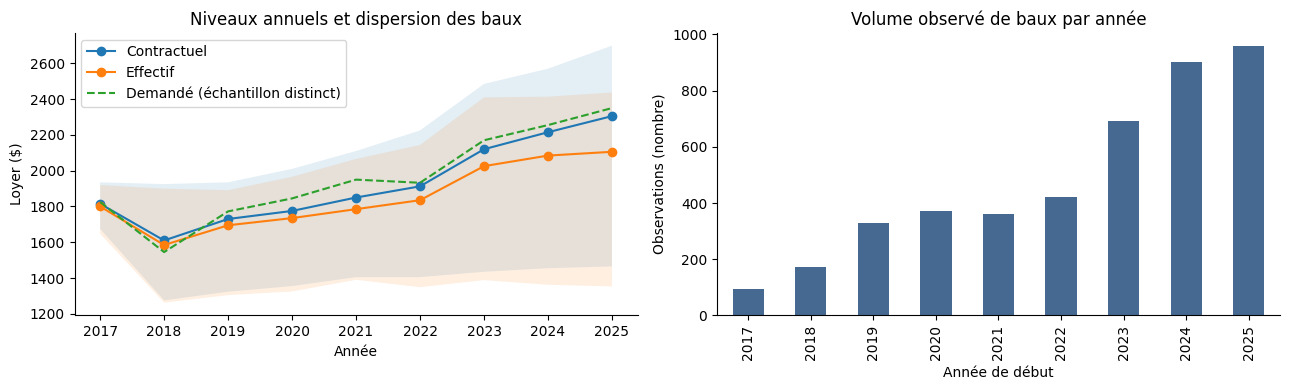

**Interprétation descriptive.** Les séries contractuelle, effective et demandée décrivent des observations de nature différente. Leur proximité ne prouve ni un appariement ni une croissance commune. Les volumes annuels montrent aussi que les pondérations implicites changent.

**Niveaux annuels par sPropCode**

sRent                                    sRentEffective  \
                effectif  moyenne médiane      Q25      Q75       effectif   
année sPropCode                                                              
2017  stelz1          93  1737.74  1815.0  1675.00  1935.00             93   
2018  levesque        64  1266.48  1352.5  1230.00  1467.50             64   
      stelz1         108  1733.89  1860.0  1672.50  1985.00            108   
2019  dj1             48  1853.85  1855.0  1296.25  2376.25             48   
      levesque        82  1329.76  1385.0  1272.50  1518.75             82   
      stelz1         103  1761.21  1900.0  1680.00  2025.00            103   
      stelz2          95  1678.68  1785.0  1552.50  1905.00             95   
2020  dj1             57  1965.00  1935.0  1330.00  2490.00             57   
      levesque        85  1371.00  1445.0  1305.00  1565.00             85   
      stelz1         104  1853.27  1977.5  1797.50  2106.25            104   
      stelz2         127  1683.86  1810.0  1547.50  1977.50            127   
2021  dj1             57  2060.09  2055.0  1395.00  2640.00             57   
      levesque        84  1426.73  1497.5  1338.75  1640.00             84   
      stelz1         101  1930.64  2050.0  1780.00  2210.00            101   
      stelz2         119  1771.30  1900.0  1610.00  2072.50            119   
2022  dj1             55  2162.91  2115.0  1482.50  2785.00             55   
      dj2             65  1837.62  1520.0  1190.00  2505.00             65   
      levesque        82  1506.59  1572.5  1415.00  1721.25             82   
      stelz1         101  2018.81  2130.0  1870.00  2330.00            101   
      stelz2         119  1856.89  2000.0  1665.00  2160.00            119   
2023  carlyle        155  1995.26  2225.0  1220.00  2570.00            155   
      dj1             57  2187.89  2155.0  1480.00  2875.00             57   
      dj2             77  1809.42  1470.0  1175.00  2470.00             77   
      levesque        83  1527.71  1580.0  1430.00  1725.00             83   
      metcalfe       104  3049.86  2667.5  2323.75  3736.25            104   
      stelz1          99  2068.13  2205.0  1867.50  2387.50             99   
      stelz2         118  1899.92  2020.0  1757.50  2216.25            118   
2024  carlyle        195  2132.92  2350.0  1290.00  2707.50            195   
      dj1             58  2288.45  2255.0  1571.25  2972.50             58   
      dj2             78  1854.42  1467.5  1226.25  2548.75             78   
      levesque        84  1596.13  1672.5  1515.00  1802.50             84   
      metcalfe       128  3145.23  2752.5  2398.75  3902.50            128   
      stelz1          96  2140.00  2270.0  1962.50  2427.50             96   
      stelz2         119  1966.76  2085.0  1782.50  2302.50            119   
      wsp1           144  1988.54  2202.5  1311.25  2445.00            144   
2025  carlyle        185  2259.81  2475.0  1385.00  2895.00            185   
      dj1             59  2449.32  2405.0  1707.50  3135.00             59   
      dj2             71  1974.44  1540.0  1325.00  2750.00             71   
      levesque        77  1741.36  1805.0  1645.00  1980.00             77   
      metcalfe       120  3397.33  2922.5  2560.00  4257.50            120   
      stelz1          36  2128.06  2305.0  1593.75  2536.25             36   
      stelz2         118  2125.72  2237.5  1911.25  2486.25            118   
      stelz3         134  1934.48  2147.5  1286.25  2387.50            134   
      wsp1           158  2110.73  2345.0  1376.25  2570.00            158   

                                                     
                 moyenne  médiane      Q25      Q75  
année sPropCode                                      
2017  stelz1     1717.45  1800.00  1648.00  1920.00  
2018  levesque   1249.64  1340.00  1222.50  1428.75  
      stelz1     1710.24  1846.70  1613.41  1981.25  
2019  dj1        1825.10  17

**Niveaux annuels par sBuilding**

sRent                                     \
                     effectif  moyenne médiane      Q25      Q75   
année sBuilding                                                    
2017  Saint-Elzear         93  1737.74  1815.0  1675.00  1935.00   
2018  Levesque             64  1266.48  1352.5  1230.00  1467.50   
      Saint-Elzear        108  1733.89  1860.0  1672.50  1985.00   
2019  Daniel-Johnson       48  1853.85  1855.0  1296.25  2376.25   
      Levesque             82  1329.76  1385.0  1272.50  1518.75   
      Saint-Elzear        198  1721.62  1840.0  1558.75  1963.75   
2020  Daniel-Johnson       57  1965.00  1935.0  1330.00  2490.00   
      Levesque             85  1371.00  1445.0  1305.00  1565.00   
      Saint-Elzear        231  1760.13  1885.0  1580.00  2020.00   
2021  Daniel-Johnson       57  2060.09  2055.0  1395.00  2640.00   
      Levesque             84  1426.73  1497.5  1338.75  1640.00   
      Saint-Elzear        220  1844.45  1957.5  1663.75  2120.00   
2022  Daniel-Johnson      120  1986.71  2007.5  1308.75  2573.75   
      Levesque             82  1506.59  1572.5  1415.00  1721.25   
      Saint-Elzear        220  1931.23  2050.0  1732.50  2236.25   
2023  Daniel-Johnson      134  1970.41  1800.0  1283.75  2617.50   
      Le Carlyle          155  1995.26  2225.0  1220.00  2570.00   
      Levesque             83  1527.71  1580.0  1430.00  1725.00   
      Saint-Elzear        217  1976.66  2100.0  1785.00  2280.00   
      The Met             104  3049.86  2667.5  2323.75  3736.25   
2024  Daniel-Johnson      136  2039.52  1870.0  1322.50  2697.50   
      Le Carlyle          195  2132.92  2350.0  1290.00  2707.50   
      Levesque             84  1596.13  1672.5  1515.00  1802.50   
      Saint-Elzear        215  2044.12  2145.0  1840.00  2385.00   
      The Met             128  3145.23  2752.5  2398.75  3902.50   
      Westpark            144  1988.54  2202.5  1311.25  2445.00   
2025  Daniel-Johnson      130  2189.96  1965.0  1393.75  2917.50   
      Le Carlyle          185  2259.81  2475.0  1385.00  2895.00   
      Levesque             77  1741.36  1805.0  1645.00  1980.00   
      Saint-Elzear        288  2037.03  2227.5  1377.50  2441.25   
      The Met             120  3397.33  2922.5  2560.00  4257.50   
      Westpark            158  2110.73  2345.0  1376.25  2570.00   

                     sRentEffective                                      
                           effectif  moyenne  médiane      Q25      Q75  
année sBuilding                                                          
2017  Saint-Elzear               93  1717.45  1800.00  1648.00  1920.00  
2018  Levesque                   64  1249.64  1340.00  1222.50  1428.75  
      Saint-Elzear              108  1710.24  1846.70  1613.41  1981.25  
2019  Daniel-Johnson             48  1825.10  1796.52  1264.77  2311.05  
      Levesque                   82  1307.80  1347.20  1252.04  1488.75  
      Saint-Elzear              198  1690.80  1792.66  1547.50  1928.50  
2020  Daniel-Johnson             57  1939.59  1935.00  1330.00  2465.00  
      Levesque                   85  1337.31  1403.69  1255.00  1512.96  
      Saint-Elzear              231  1722.35  1860.61  1538.92  1982.50  
2021  Daniel-Johnson             57  2005.38  1980.00  1340.40  2565.99  
      Levesque                   84  1391.79  1465.00  1312.48  1586.27  
      Saint-Elzear              220  1793.12  1908.88  1596.41  2082.62  
2022  Daniel-Johnson            120  1924.13  1882.80  1242.04  2518.75  
      Levesque                   82  1454.01  1526.46  1377.24  1649.34  
      Saint-Elzear              220  1863.39  1974.07  1666.34  2161.50  
2023  Daniel-Johnson            134  1912.19  1736.48  1234.90  2462.76  
      Le Carlyle                155  1916.41  2145.00  1185.00  2441.37  
      Levesque                   83  1479.79  1525.16  1364.62  1708.68  
      Saint-Elzear              217  1907.26  2016.85  1690.00  2199.72  
      The Met  

...

sRent                                    sRentEffective  \
              effectif  moyenne médiane      Q25      Q75       effectif   
année sState                                                               
2017  Quebec        93  1737.74  1815.0  1675.00  1935.00             93   
2018  Quebec       172  1559.97  1610.0  1275.00  1925.00            172   
2019  Quebec       328  1643.00  1730.0  1323.75  1935.00            328   
2020  Quebec       373  1702.76  1775.0  1355.00  2010.00            373   
2021  Quebec       361  1781.30  1850.0  1405.00  2110.00            361   
2022  Quebec       422  1864.49  1912.5  1405.00  2225.00            422   
2023  Ontario      104  3049.86  2667.5  2323.75  3736.25            104   
      Quebec       589  1916.87  1980.0  1340.00  2350.00            589   
2024  Ontario      128  3145.23  2752.5  2398.75  3902.50            128   
      Quebec       774  2006.72  2102.5  1375.00  2455.00            774   
2025  Ontario      120  3397.33  2922.5  2560.00  4257.50            120   
      Quebec       838  2096.66  2180.0  1395.00  2565.00            838   

                                                   
               moyenne  médiane      Q25      Q75  
année sState                                       
2017  Quebec   1717.45  1800.00  1648.00  1920.00  
2018  Quebec   1538.85  1584.58  1262.50  1899.42  
2019  Quebec   1614.71  1694.84  1304.40  1891.02  
2020  Quebec   1667.80  1735.00  1325.00  1965.81  
2021  Quebec   1733.25  1785.00  1390.00  2065.67  
2022  Quebec   1801.12  1835.00  1348.80  2143.75  
2023  Ontario  2911.01  2582.50  2233.12  3650.96  
      Quebec   1850.55  1880.86  1293.20  2260.00  
2024  Ontario  2945.44  2544.97  2277.11  3625.70  
      Quebec   1892.99  1990.68  1284.22  2318.80  
2025  Ontario  3045.16  2597.40  2278.40  3787.91  
      Quebec   1907.31  1987.58  1281.87  2331.30

**Niveaux annuels par sBeds**

sRent                                    sRentEffective  \
            effectif  moyenne médiane      Q25      Q75       effectif   
année sBeds                                                              
2017  1           17  1044.71  1075.0  1035.00  1095.00             17   
      2           74  1875.61  1887.5  1753.75  1952.50             74   
      3            2      NaN     NaN      NaN      NaN              2   
2018  1           35   886.43   895.0   662.50  1080.00             35   
      2          133  1713.38  1755.0  1465.00  1950.00            133   
      3            4      NaN     NaN      NaN      NaN              4   
2019  1           70  1023.79  1067.5   892.50  1157.50             70   
      2          251  1794.32  1810.0  1545.00  1962.50            251   
      3            7  2409.29  2160.0  2135.00  2630.00              7   
2020  1           83  1056.39  1085.0   932.50  1192.50             83   
      2          279  1861.54  1880.0  1610.00  2025.00            279   
      3           11  2552.73  2315.0  2170.00  3055.00             11   
2021  1           78  1108.21  1142.5   951.25  1258.75             78   
      2          275  1942.60  1950.0  1680.00  2132.50            275   
      3            8  2799.38  2827.5  2353.75  3256.25              8   
2022  0           10  1138.50  1155.0  1050.00  1207.50             10   
      1          106  1196.84  1197.5  1082.50  1323.75            106   
      2          296  2091.98  2087.5  1803.75  2301.25            296   
      3           10  2934.00  2950.0  2467.50  3423.75             10   
2023  0           44  2135.91  2260.0  1293.75  2622.50             44   
      1          215  1449.91  1250.0  1145.00  1572.50            215   
      2          420  2379.62  2245.0  1973.75  2586.25            420   
      3           14  2933.57  2782.5  2576.25  3373.75             14   
2024  0           50  2236.40  2325.0  2103.75  2733.75             50   
      1          291  1496.53  1290.0  1172.50  1555.00            291   
      2          544  2492.70  2355.0  2103.75  2681.25            544   
      3           17  3085.59  2955.0  2775.00  3380.00             17   
2025  0           48  2423.54  2520.0  2285.00  2866.25             48   
      1          333  1536.19  1345.0  1240.00  1555.00            333   
      2          557  2644.32  2475.0  2230.00  2835.00            557   
      3           20  3196.00  3137.5  2922.50  3512.50             20   

                                                 
             moyenne  médiane      Q25      Q75  
année sBeds                                      
2017  1      1033.79  1045.00  1019.59  1075.00  
      2      1852.62  1859.42  1720.12  1930.00  
      3          NaN      NaN      NaN      NaN  
2018  1       875.71   895.00   662.12  1060.14  
      2      1690.10  1706.62  1418.03  1930.00  
      3          NaN      NaN      NaN      NaN  
2019  1      1009.50  1047.50   878.75  1145.00  
      2      1761.33  1781.23  1522.18  1927.90  
      3      2409.29  2160.00  2135.00  2630.00  
2020  1      1034.54  1052.54   905.03  1167.23  
      2      1824.28  1855.00  1566.64  1990.00  
      3      2477.26  2227.87  2125.62  2922.77  
2021  1      1076.89  1105.00   937.50  1228.73  
      2      1890.79  1903.45  1630.52  2093.77  
      3      2717.30  2685.48  2273.73  3178.44  
2022  0      1104.97  1080.46  1013.75  1178.73  
      1      1163.40  1165.45  1035.24  1305.00  
      2      2018.18  2004.88  1758.75  2237.70  
      3      2831.98  2880.80  2467.50  3282.85  
2023  0      2040.48  2210.00  1293.75  2457.46  
      1      1400.27  1220.00  1083.90  1542.50  
      2      2289.06  2151.13  1875.00  2470.00  
      3      2890.96  2733.90  2523.75  3373.75  
2024  0      2097.78  2230.05  1932.26  2529.87  
      1      1408.81  1218.84  1099.92  1471.98  
      2      2349.23  2225.00  1990.69  2511.53  
      3      2903.17  2735.81  2628.61  3380.00 

**Niveaux annuels par sUnitSubtype**

sRent                                    sRentEffective  \
                   effectif  moyenne médiane      Q25      Q75       effectif   
année sUnitSubtype                                                              
2017  1 Bed              17  1044.71  1075.0  1035.00  1095.00             17   
      2 Bed              74  1875.61  1887.5  1753.75  1952.50             74   
      3 Bed               2      NaN     NaN      NaN      NaN              2   
2018  1 Bed              35   886.43   895.0   662.50  1080.00             35   
      2 Bed             133  1713.38  1755.0  1465.00  1950.00            133   
      3 Bed               4      NaN     NaN      NaN      NaN              4   
2019  1 Bed              70  1023.79  1067.5   892.50  1157.50             70   
      2 Bed             251  1794.32  1810.0  1545.00  1962.50            251   
      3 Bed               7  2409.29  2160.0  2135.00  2630.00              7   
2020  1 Bed              83  1056.39  1085.0   932.50  1192.50             83   
      2 Bed             279  1861.54  1880.0  1610.00  2025.00            279   
      3 Bed              11  2552.73  2315.0  2170.00  3055.00             11   
2021  1 Bed              78  1108.21  1142.5   951.25  1258.75             78   
      2 Bed             275  1942.60  1950.0  1680.00  2132.50            275   
      3 Bed               8  2799.38  2827.5  2353.75  3256.25              8   
2022  1 Bed             106  1196.84  1197.5  1082.50  1323.75            106   
      2 Bed             296  2091.98  2087.5  1803.75  2301.25            296   
      3 Bed              10  2934.00  2950.0  2467.50  3423.75             10   
      Studio             10  1138.50  1155.0  1050.00  1207.50             10   
2023  1 Bed             215  1449.91  1250.0  1145.00  1572.50            215   
      2 Bed             420  2379.62  2245.0  1973.75  2586.25            420   
      3 Bed              14  2933.57  2782.5  2576.25  3373.75             14   
      Studio             44  2135.91  2260.0  1293.75  2622.50             44   
2024  1 Bed             291  1496.53  1290.0  1172.50  1555.00            291   
      2 Bed             544  2492.70  2355.0  2103.75  2681.25            544   
      3 Bed              17  3085.59  2955.0  2775.00  3380.00             17   
      Studio             50  2236.40  2325.0  2103.75  2733.75             50   
2025  1 Bed             333  1536.19  1345.0  1240.00  1555.00            333   
      2 Bed             557  2644.32  2475.0  2230.00  2835.00            557   
      3 Bed              20  3196.00  3137.5  2922.50  3512.50             20   
      Studio             48  2423.54  2520.0  2285.00  2866.25             48   

                                                        
                    moyenne  médiane      Q25      Q75  
année sUnitSubtype                                      
2017  1 Bed         1033.79  1045.00  1019.59  1075.00  
      2 Bed         1852.62  1859.42  1720.12  1930.00  
      3 Bed             NaN      NaN      NaN      NaN  
2018  1 Bed          875.71   895.00   662.12  1060.14  
      2 Bed         1690.10  1706.62  1418.03  1930.00  
      3 Bed             NaN      NaN      NaN      NaN  
2019  1 Bed         1009.50  1047.50   878.75  1145.00  
      2 Bed         1761.33  1781.23  1522.18  1927.90  
      3 Bed         2409.29  2160.00  2135.00  2630.00  
2020  1 Bed         1034.54  1052.54   905.03  1167.23  
      2 Bed         1824.28  1855.00  1566.64  1990.00  
      3 Bed         2477.26  2227.87  2125.62  2922.77  
2021  1 Bed         1076.89  1105.00   937.50  1228.73  
      2 Bed         1890.79  1903.45  1630.52  2093.77  
      3 Bed         2717.30  2685.48  2273.73  3178.44  
2022  1 Bed         1163.40  1165.45  1035.24  1305.00  
      2 Bed         2018.18  2004.88  1758.75  2237.70  
      3 Bed         2831.98  2880.80  2467.50  3282.85  
      Studio        1104.97  1080.46  1013.75  1178.73  
2023  1 Bed  

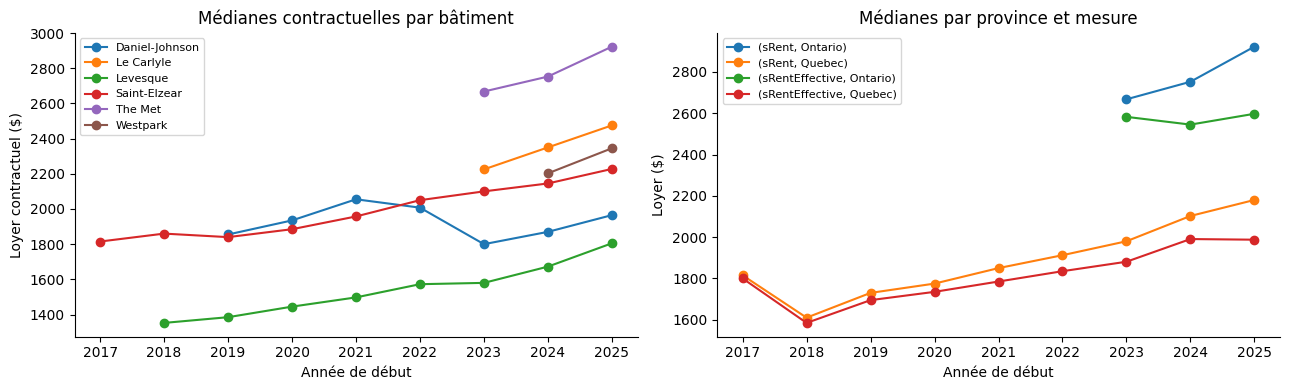

**Interprétation descriptive.** Les segments ont des niveaux et des débuts de couverture différents. Une première apparition dans ces courbes prouve une entrée dans l’historique observé, pas une ouverture physique du bâtiment.

In [3]:
annual = stats(leases, ['année'], ['sRent', 'sRentEffective'])
asking_annual = stats(asking, ['année'], ['sAskingRent'])
display(annual)
display(asking_annual)
level_changes = leases.groupby('année')[['sRent', 'sRentEffective']].median().pct_change().mul(100)
display(level_changes.rename(columns={'sRent': 'variation brute médiane contractuelle (%)',
                                     'sRentEffective': 'variation brute médiane effective (%)'}).round(2))
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
for col, label in [('sRent', 'Contractuel'), ('sRentEffective', 'Effectif')]:
    a = annual[col]
    axes[0].plot(a.index, a['médiane'], marker='o', label=label)
    axes[0].fill_between(a.index, a['Q25'], a['Q75'], alpha=.12)
aw = asking_annual.loc[asking_annual.index.isin(YEARS), 'sAskingRent']
axes[0].plot(aw.index, aw['médiane'], '--', label='Demandé (échantillon distinct)')
axes[0].set(title='Niveaux annuels et dispersion des baux', xlabel='Année', ylabel='Loyer ($)')
axes[0].legend()
leases.groupby('année').size().plot.bar(ax=axes[1], color='#456990')
axes[1].set(title='Volume observé de baux par année', xlabel='Année de début', ylabel='Observations (nombre)')
plt.tight_layout(); plt.show()
note('Les séries contractuelle, effective et demandée décrivent des observations de nature différente. Leur proximité ne prouve ni un appariement ni une croissance commune. Les volumes annuels montrent aussi que les pondérations implicites changent.')
for col in ['sPropCode', 'sBuilding', 'sState', 'sBeds', 'sUnitSubtype']:
    display(Markdown(f'**Niveaux annuels par {col}**'))
    display(stats(leases, ['année', col], ['sRent', 'sRentEffective']))
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
leases.groupby(['année', 'sBuilding'])['sRent'].median().where(leases.groupby(['année', 'sBuilding']).size().ge(MIN_DISPLAY)).unstack().plot(ax=axes[0], marker='o')
leases.groupby(['année', 'sState'])[['sRent', 'sRentEffective']].median().where(leases.groupby(['année', 'sState']).size().ge(MIN_DISPLAY), axis=0).unstack().plot(ax=axes[1], marker='o')
axes[0].set(title='Médianes contractuelles par bâtiment', xlabel='Année de début', ylabel='Loyer contractuel ($)')
axes[1].set(title='Médianes par province et mesure', xlabel='Année de début', ylabel='Loyer ($)')
axes[0].legend(fontsize=8); axes[1].legend(fontsize=8)
plt.tight_layout(); plt.show()
note('Les segments ont des niveaux et des débuts de couverture différents. Une première apparition dans ces courbes prouve une entrée dans l’historique observé, pas une ouverture physique du bâtiment.')

## 3. Effet de composition : parts historiques et décomposition descriptive

Chaque part est calculée sur les **baux observés de l’année**. Les tableaux de caractéristiques historiques résument les unités concernées par ces baux ; ils ne reconstituent pas un stock annuel exhaustif.

Pour quantifier le problème, on décompose l’écart de **moyenne contractuelle** entre 2021 et 2024. Sur les bâtiments observés aux deux dates, l’identité symétrique suivante sépare la variation des parts et celle des moyennes par bâtiment :

- contribution des parts : somme de `(part_2024 − part_2021) × (moyenne_2024 + moyenne_2021) / 2` ;
- contribution des niveaux : somme de `(moyenne_2024 − moyenne_2021) × (part_2024 + part_2021) / 2`.

Les parts sont normalisées au sein des bâtiments communs. Les deux contributions reproduisent exactement leur écart moyen. On ajoute ensuite l’écart entre chaque moyenne globale et celle des bâtiments communs, ce qui mesure la contribution descriptive de la couverture différente. Aucune moyenne non observée n’est imputée. La contribution « niveaux » reste sensible au mix des unités et des baux **au sein** d’un bâtiment ; ce n’est pas une croissance same-unit, ni une attribution causale.

**Parts annuelles par propriété (%)**

sPropCode,carlyle,dj1,dj2,levesque,metcalfe,stelz1,stelz2,stelz3,wsp1
année,,,,,,,,,
2017,0.00,0.00,0.00,0.00,0.00,100.00,0.00,0.00,0.00
2018,0.00,0.00,0.00,37.21,0.00,62.79,0.00,0.00,0.00
2019,0.00,14.63,0.00,25.00,0.00,31.40,28.96,0.00,0.00
2020,0.00,15.28,0.00,22.79,0.00,27.88,34.05,0.00,0.00
2021,0.00,15.79,0.00,23.27,0.00,27.98,32.96,0.00,0.00
2022,0.00,13.03,15.40,19.43,0.00,23.93,28.20,0.00,0.00
2023,22.37,8.23,11.11,11.98,15.01,14.29,17.03,0.00,0.00
2024,21.62,6.43,8.65,9.31,14.19,10.64,13.19,0.00,15.96
2025,19.31,6.16,7.41,8.04,12.53,3.76,12.32,13.99,16.49


**Parts annuelles par bâtiment (%)**

sBuilding,Daniel-Johnson,Le Carlyle,Levesque,Saint-Elzear,The Met,Westpark
année,,,,,,
2017,0.00,0.00,0.00,100.00,0.00,0.00
2018,0.00,0.00,37.21,62.79,0.00,0.00
2019,14.63,0.00,25.00,60.37,0.00,0.00
2020,15.28,0.00,22.79,61.93,0.00,0.00
2021,15.79,0.00,23.27,60.94,0.00,0.00
2022,28.44,0.00,19.43,52.13,0.00,0.00
2023,19.34,22.37,11.98,31.31,15.01,0.00
2024,15.08,21.62,9.31,23.84,14.19,15.96
2025,13.57,19.31,8.04,30.06,12.53,16.49


**Parts annuelles par chambres (%)**

sBeds,0,1,2,3
année,,,,
2017,0.00,18.28,79.57,2.15
2018,0.00,20.35,77.33,2.33
2019,0.00,21.34,76.52,2.13
2020,0.00,22.25,74.80,2.95
2021,0.00,21.61,76.18,2.22
2022,2.37,25.12,70.14,2.37
2023,6.35,31.02,60.61,2.02
2024,5.54,32.26,60.31,1.88
2025,5.01,34.76,58.14,2.09


**Parts annuelles par sous-type (%)**

sUnitSubtype,1 Bed,2 Bed,3 Bed,Studio
année,,,,
2017,18.28,79.57,2.15,0.00
2018,20.35,77.33,2.33,0.00
2019,21.34,76.52,2.13,0.00
2020,22.25,74.80,2.95,0.00
2021,21.61,76.18,2.22,0.00
2022,25.12,70.14,2.37,2.37
2023,31.02,60.61,2.02,6.35
2024,32.26,60.31,1.88,5.54
2025,34.76,58.14,2.09,5.01


,observations,bâtiments,superficie_médiane,superficie_moyenne,chambres_moyennes,salles_bain_moyennes,étage_médian,part 2 chambres et plus (%),loyer médian ($/pi²)
année,,,,,,,,,
2017,93,1.0,1290.0,1191.24,1.84,1.57,10.0,81.72,1.46
2018,172,2.0,1170.0,1127.91,1.82,1.55,11.0,79.65,1.43
2019,328,3.0,1177.5,1120.52,1.81,1.32,11.0,78.66,1.48
2020,373,3.0,1180.0,1120.62,1.81,1.32,11.0,77.75,1.53
2021,361,3.0,1175.0,1121.26,1.81,1.31,11.0,78.39,1.60
2022,422,3.0,1160.0,1080.97,1.73,1.27,11.0,72.51,1.71
2023,693,5.0,1095.0,995.11,1.58,1.26,8.0,62.63,2.04
2024,902,6.0,1045.0,967.31,1.59,1.28,7.0,62.20,2.20
2025,958,6.0,1025.0,956.44,1.57,1.26,7.0,60.23,2.33


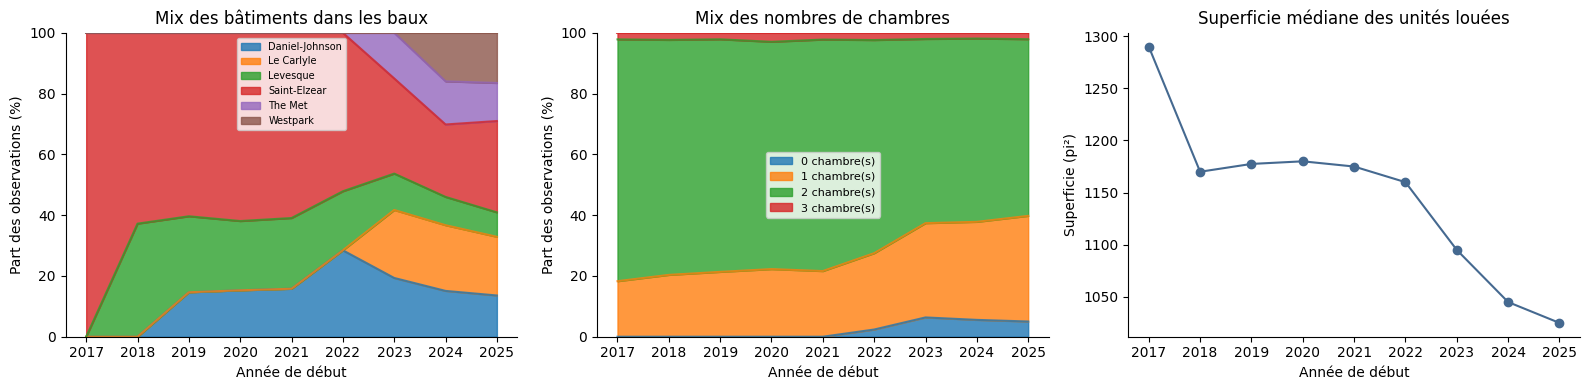

**Interprétation descriptive.** Les parts des bâtiments et des chambres doivent être lues avec les volumes annuels. Les changements de superficie et de composition peuvent déplacer une statistique globale même en l’absence de croissance uniforme des unités.

,Contribution ($)
Changement des parts (bâtiments communs),33.46
Changement des niveaux (bâtiments communs),141.41
Différence de couverture des bâtiments,212.11
Écart moyen global 2024 − 2021,386.99


,part 2021 (%),part 2024 (%),moyenne 2021 ($),moyenne 2024 ($)
sBuilding,,,,
Daniel-Johnson,15.79,31.26,2060.09,2039.52
Levesque,23.27,19.31,1426.73,1596.13
Saint-Elzear,60.94,49.43,1844.45,2044.12


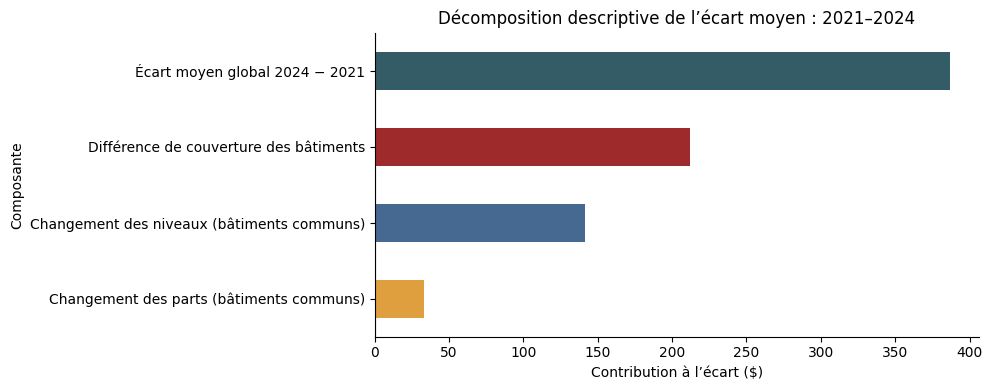

**Interprétation descriptive.** La moyenne globale augmente de 386.99 $. La différence de couverture contribue à hauteur de 212.11 $, et les parts des bâtiments communs de 33.46 $. La composante restante (141.41 $) mélange évolution des prix et composition interne. Le choix 2021–2024 suit le contraste signalé dans le starter ; il ne fixe pas une pondération finale.

In [4]:
building_shares = shares(leases, 'sBuilding')
property_shares = shares(leases, 'sPropCode')
bed_shares = shares(leases, 'sBeds')
subtype_shares = shares(leases, 'sUnitSubtype')
for label, table in [('propriété', property_shares), ('bâtiment', building_shares),
                     ('chambres', bed_shares), ('sous-type', subtype_shares)]:
    display(Markdown(f'**Parts annuelles par {label} (%)**'))
    display(table.round(2))
historical_mix = leases.groupby('année').agg(
    observations=('sRent', 'size'), bâtiments=('sBuilding', 'nunique'),
    superficie_médiane=('sSqft', 'median'), superficie_moyenne=('sSqft', 'mean'),
    chambres_moyennes=('sBeds', 'mean'), salles_bain_moyennes=('sBaths', 'mean'),
    étage_médian=('sFloor', 'median'), part_2_chambres_plus=('sBeds', lambda x: x.ge(2).mean()*100))
valid_area = leases['sSqft'].gt(0)
price_area = leases.loc[valid_area, ['année', 'sRent', 'sSqft']].assign(
    loyer_pi2=lambda d: d['sRent']/d['sSqft']).groupby('année')['loyer_pi2'].median()
historical_mix['loyer_pi2_médian'] = price_area
historical_mix = historical_mix.rename(columns={'part_2_chambres_plus': 'part 2 chambres et plus (%)',
                                                'loyer_pi2_médian': 'loyer médian ($/pi²)'})
display(historical_mix.round(2))
fig, axes = plt.subplots(1, 3, figsize=(16, 4))
building_shares.plot.area(ax=axes[0], alpha=.8)
bed_shares.rename(columns=lambda c: f'{c} chambre(s)').plot.area(ax=axes[1], alpha=.8)
historical_mix['superficie_médiane'].plot(ax=axes[2], marker='o', color='#456990')
axes[0].set(title='Mix des bâtiments dans les baux', xlabel='Année de début', ylabel='Part des observations (%)', ylim=(0,100))
axes[1].set(title='Mix des nombres de chambres', xlabel='Année de début', ylabel='Part des observations (%)', ylim=(0,100))
axes[2].set(title='Superficie médiane des unités louées', xlabel='Année de début', ylabel='Superficie (pi²)')
axes[0].legend(fontsize=7); axes[1].legend(fontsize=8)
plt.tight_layout(); plt.show()
note('Les parts des bâtiments et des chambres doivent être lues avec les volumes annuels. Les changements de superficie et de composition peuvent déplacer une statistique globale même en l’absence de croissance uniforme des unités.')

base, end = 2021, 2024
counts = leases.groupby(['année', 'sBuilding']).size().unstack(fill_value=0)
means = leases.groupby(['année', 'sBuilding'])['sRent'].mean().unstack()
common = counts.columns[(counts.loc[base] > 0) & (counts.loc[end] > 0)]
w0 = counts.loc[base, common] / counts.loc[base, common].sum()
w1 = counts.loc[end, common] / counts.loc[end, common].sum()
m0, m1 = means.loc[base, common], means.loc[end, common]
part_effect = ((w1-w0)*(m1+m0)/2).sum()
level_effect = ((m1-m0)*(w1+w0)/2).sum()
common0, common1 = (w0*m0).sum(), (w1*m1).sum()
overall = leases.groupby('année')['sRent'].mean()
coverage_effect = (overall.loc[end]-common1) - (overall.loc[base]-common0)
total_change = overall.loc[end]-overall.loc[base]
assert np.isclose(part_effect + level_effect + coverage_effect, total_change)
decomposition = pd.Series({'Changement des parts (bâtiments communs)': part_effect,
                           'Changement des niveaux (bâtiments communs)': level_effect,
                           'Différence de couverture des bâtiments': coverage_effect,
                           'Écart moyen global 2024 − 2021': total_change}, name='Contribution ($)')
display(decomposition.round(2).to_frame())
display(pd.DataFrame({'part 2021 (%)': w0*100, 'part 2024 (%)': w1*100,
                      'moyenne 2021 ($)': m0, 'moyenne 2024 ($)': m1}).round(2))
fig, ax = plt.subplots(figsize=(10,4))
decomposition.plot.barh(ax=ax, color=['#e09f3e','#456990','#9e2a2b','#335c67'])
ax.axvline(0, color='grey', linewidth=.8)
ax.set(title='Décomposition descriptive de l’écart moyen : 2021–2024', xlabel='Contribution à l’écart ($)', ylabel='Composante')
plt.tight_layout(); plt.show()
note(f'La moyenne globale augmente de {total_change:.2f} $. La différence de couverture contribue à hauteur de {coverage_effect:.2f} $, et les parts des bâtiments communs de {part_effect:.2f} $. La composante restante ({level_effect:.2f} $) mélange évolution des prix et composition interne. Le choix 2021–2024 suit le contraste signalé dans le starter ; il ne fixe pas une pondération finale.')

## 4. Loyer contractuel et loyer effectif : écarts et stabilité

L’écart absolu est `sRent − sRentEffective`. L’écart relatif est cet écart divisé par `sRent`, uniquement si le loyer contractuel est strictement positif. Ces calculs décrivent deux champs du **même bail** ; aucune conversion de l’un en l’autre n’est ajustée.

La corrélation de Pearson est descriptive. Une forte corrélation peut coexister avec un écart systématique, variable selon l’année ou le segment. Les distributions sont regroupées en classes, sans points individuels.

Dénominateurs non positifs exclus du calcul relatif : 0
Écarts négatifs observés : 0
Corrélation descriptive de Pearson : 0.9917


écart ($)                                 écart (%)                  \
       effectif moyenne médiane     Q25     Q75  effectif moyenne médiane   
année                                                                       
2017         93   20.29    0.00    0.00   49.83        93    1.18    0.00   
2018        172   21.12    0.00    0.00   48.51       172    1.36    0.00   
2019        328   28.30    0.00    0.00   62.39       328    1.70    0.00   
2020        373   34.96    0.00    0.00   70.96       373    2.09    0.00   
2021        361   48.05   48.40    0.00   91.58       361    2.69    4.09   
2022        422   63.37   69.72    0.00  115.32       422    3.33    4.91   
2023        693   77.20   71.23    0.00  146.00       693    3.58    5.41   
2024        902  125.95  134.67    0.00  194.01       902    5.71    7.20   
2025        958  209.75  219.92  131.86  289.30       958    9.13   10.31   

                    
        Q25    Q75  
année               
2017   0.00   2.82  
2018   0.00   3.40  
2019   0.00   3.75  
2020   0.00   4.21  
2021   0.00   5.03  
2022   0.00   5.93  
2023   0.00   6.64  
2024   0.00   8.29  
2025   9.02  11.55

écart ($)                                 écart (%)                  \
           effectif moyenne médiane     Q25     Q75  effectif moyenne médiane   
sPropCode                                                                       
carlyle         535  151.60  149.91   76.43  227.36       535    6.91    7.74   
dj1             391   86.02   61.42    0.00  149.10       391    3.85    4.00   
dj2             291   91.73   77.73    0.00  149.58       291    4.68    5.86   
levesque        641   54.56   42.95    0.00   90.90       641    3.47    3.68   
metcalfe        352  233.73  226.12  154.43  315.27       352    7.15    7.58   
stelz1          841   56.57   33.75    0.00   95.21       841    2.81    2.77   
stelz2          815   75.11   66.90    0.00  123.62       815    3.89    4.23   
stelz3          134  156.77  156.50  101.83  246.92       134    8.13    9.68   
wsp1            302  170.55  165.93  113.14  239.45       302    8.27    8.97   

                        
            Q25    Q75  
sPropCode               
carlyle    5.90   9.61  
dj1        0.00   6.92  
dj2        0.00   8.17  
levesque   0.00   5.96  
metcalfe   6.02   9.52  
stelz1     0.00   5.15  
stelz2     0.00   6.47  
stelz3     8.59  11.36  
wsp1       7.25  10.43

écart ($)                                 écart (%)          \
                effectif moyenne médiane     Q25     Q75  effectif moyenne   
sBuilding                                                                    
Daniel-Johnson       682   88.46   68.88    0.00  149.24       682    4.20   
Le Carlyle           535  151.60  149.91   76.43  227.36       535    6.91   
Levesque             641   54.56   42.95    0.00   90.90       641    3.47   
Saint-Elzear        1790   72.51   58.68    0.00  121.80      1790    3.70   
The Met              352  233.73  226.12  154.43  315.27       352    7.15   
Westpark             302  170.55  165.93  113.14  239.45       302    8.27   

                                     
               médiane   Q25    Q75  
sBuilding                            
Daniel-Johnson    4.62  0.00   7.53  
Le Carlyle        7.74  5.90   9.61  
Levesque          3.68  0.00   5.96  
Saint-Elzear      3.66  0.00   6.36  
The Met           7.58  6.02   9.52  
Westpark          8.97  7.25  10.43

écart ($)                                 écart (%)                  \
         effectif moyenne médiane     Q25     Q75  effectif moyenne médiane   
sState                                                                        
Ontario       352  233.73  226.12  154.43  315.27       352    7.15    7.58   
Quebec       3950   90.56   74.64    0.00  149.22      3950    4.53    4.66   

                     
          Q25   Q75  
sState               
Ontario  6.02  9.52  
Quebec   0.00  7.90

écart ($)                              écart (%)                  \
          effectif moyenne médiane  Q25     Q75  effectif moyenne médiane   
sRenewal                                                                    
0             2337   97.86   76.00  0.0  160.16      2337    4.58    4.77   
1             1965  107.52   89.06  0.0  168.02      1965    4.95    5.32   

                     
          Q25   Q75  
sRenewal             
0         0.0  7.92  
1         0.0  8.44

écart ($)                                 écart (%)          \
               effectif moyenne médiane     Q25     Q75  effectif moyenne   
année sState                                                                
2017  Quebec         93   20.29    0.00    0.00   49.83        93    1.18   
2018  Quebec        172   21.12    0.00    0.00   48.51       172    1.36   
2019  Quebec        328   28.30    0.00    0.00   62.39       328    1.70   
2020  Quebec        373   34.96    0.00    0.00   70.96       373    2.09   
2021  Quebec        361   48.05   48.40    0.00   91.58       361    2.69   
2022  Quebec        422   63.37   69.72    0.00  115.32       422    3.33   
2023  Ontario       104  138.85  150.88    0.00  203.45       104    4.51   
      Quebec        589   66.32   59.73    0.00  132.52       589    3.41   
2024  Ontario       128  199.79  203.30  159.32  264.18       128    6.30   
      Quebec        774  113.73  117.16    0.00  180.07       774    5.61   
2025  Ontario       120  352.17  315.51  269.83  442.95       120   10.34   
      Quebec        838  189.36  200.49  124.43  270.38       838    8.96   

                                    
              médiane   Q25    Q75  
année sState                        
2017  Quebec     0.00  0.00   2.82  
2018  Quebec     0.00  0.00   3.40  
2019  Quebec     0.00  0.00   3.75  
2020  Quebec     0.00  0.00   4.21  
2021  Quebec     4.09  0.00   5.03  
2022  Quebec     4.91  0.00   5.93  
2023  Ontario    5.83  0.00   6.78  
      Quebec     5.24  0.00   6.59  
2024  Ontario    7.19  6.19   8.23  
      Quebec     7.20  0.00   8.30  
2025  Ontario   10.44  9.43  11.70  
      Quebec    10.23  8.94  11.50

écart ($)                                 écart (%)          \
                effectif moyenne médiane     Q25     Q75  effectif moyenne   
année sRenewal                                                               
2017  0               91   19.98    0.00    0.00   49.67        91    1.17   
      1                2     NaN     NaN     NaN     NaN         2     NaN   
2018  0              121   18.07    0.00    0.00   44.69       121    1.27   
      1               51   28.36    0.00    0.00   65.03        51    1.57   
2019  0              231   27.39    0.00    0.00   58.86       231    1.64   
      1               97   30.45    0.00    0.00   64.72        97    1.85   
2020  0              172   36.12   14.69    0.00   71.11       172    2.13   
      1              201   33.96    0.00    0.00   70.71       201    2.05   
2021  0              136   47.11   48.77    0.00   88.79       136    2.65   
      1              225   48.62   48.28    0.00   94.71       225    2.71   
2022  0              190   57.17   58.08    0.00  110.14       190    3.10   
      1              232   68.45   81.81    0.00  119.06       232    3.51   
2023  0              447   84.93   81.48    0.00  149.68       447    3.81   
      1              246   63.16    0.00    0.00  135.12       246    3.16   
2024  0              474  130.81  143.26   77.81  193.73       474    6.03   
      1              428  120.56  126.65    0.00  194.71       428    5.35   
2025  0              475  199.84  210.82  118.69  281.07       475    8.81   
      1              483  219.50  224.03  138.65  298.00       483    9.45   

                                     
               médiane   Q25    Q75  
année sRenewal                       
2017  0           0.00  0.00   2.82  
      1            NaN   NaN    NaN  
2018  0           0.00  0.00   3.30  
      1           0.00  0.00   3.55  
2019  0           0.00  0.00   3.74  
      1           0.00  0.00   3.75  
2020  0           1.64  0.00   4.24  
      1           0.00  0.00   4.18  
2021  0           4.00  0.00   4.94  
      1           4.18  0.00   5.05  
2022  0           4.66  0.00   5.78  
      1           5.08  0.00   6.06  
2023  0           5.58  0.00   6.70  
      1           0.00  0.00   6.55  
2024  0           7.31  6.06   8.35  
      1           7.09  0.00   8.18  
2025  0          10.11  8.85  11.53  
      1          10.43  9.16  11.57

,écart_moyen,écart_relatif_moyen,écart_relatif_médian,part_avec_concession,corrélation
année,,,,,
2017,20.288,1.179,0.000,38.710,0.997
2018,21.118,1.355,0.000,38.372,0.998
2019,28.297,1.703,0.000,44.207,0.997
2020,34.960,2.088,0.000,48.794,0.997
2021,48.050,2.690,4.086,54.017,0.995
2022,63.373,3.326,4.907,57.346,0.995
2023,77.202,3.576,5.410,54.257,0.995
2024,125.947,5.707,7.199,73.060,0.994
2025,209.754,9.132,10.305,85.386,0.993


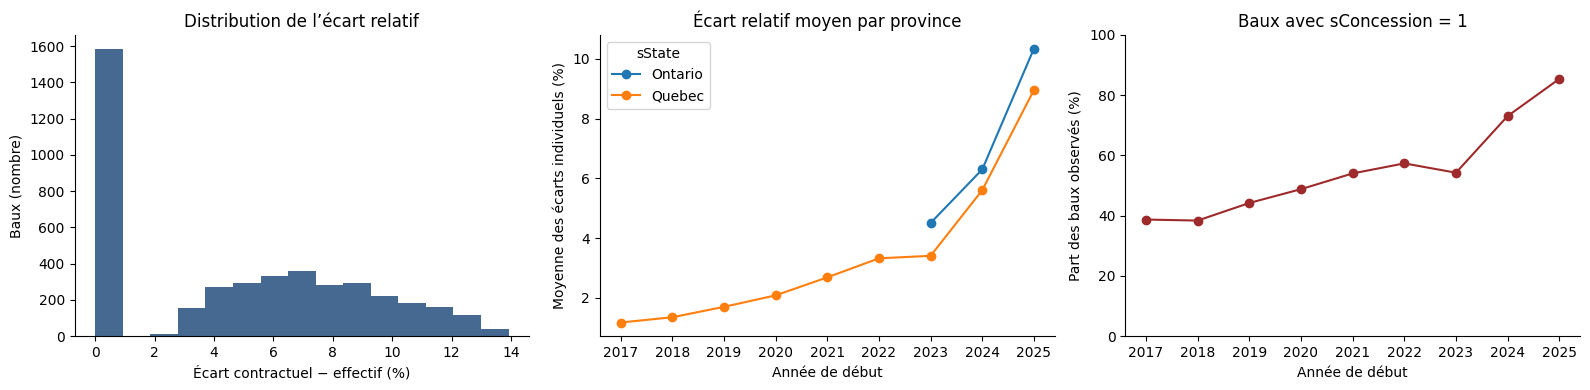

**Interprétation descriptive.** La corrélation globale est 0.9917. Les champs restent distincts : les tableaux par année et segment mesurent le changement de leurs écarts. La moyenne des ratios individuels diffère du ratio des moyennes ou des médianes.

In [5]:
leases['écart ($)'] = leases['sRent'] - leases['sRentEffective']
leases['écart (%)'] = leases['écart ($)'].div(leases['sRent'].where(leases['sRent'].gt(0))).mul(100)
print('Dénominateurs non positifs exclus du calcul relatif :', int(leases['sRent'].le(0).sum()))
print('Écarts négatifs observés :', int(leases['écart ($)'].lt(0).sum()))
correlation = leases['sRent'].corr(leases['sRentEffective'])
print('Corrélation descriptive de Pearson :', round(correlation, 4))
for grouping in [['année'], ['sPropCode'], ['sBuilding'], ['sState'], ['sRenewal'], ['année','sState'], ['année','sRenewal']]:
    display(stats(leases, grouping, ['écart ($)', 'écart (%)']))
gap_annual = leases.groupby('année').agg(
    écart_moyen=('écart ($)', 'mean'), écart_relatif_moyen=('écart (%)', 'mean'),
    écart_relatif_médian=('écart (%)', 'median'),
    part_avec_concession=('sConcession', lambda x: x.eq(1).mean()*100),
    corrélation=('sRent', lambda x: x.corr(leases.loc[x.index, 'sRentEffective'])))
display(gap_annual.round(3))
# Histogramme à partir d’effectifs agrégés ; aucune observation individuelle dans les sorties.
gap_values = leases['écart (%)'].dropna()
gap_counts, edges = np.histogram(gap_values, bins=15)
fig, axes = plt.subplots(1, 3, figsize=(16,4))
axes[0].bar(edges[:-1], gap_counts, width=np.diff(edges), align='edge', color='#456990')
axes[0].set(title='Distribution de l’écart relatif', xlabel='Écart contractuel − effectif (%)', ylabel='Baux (nombre)')
leases.groupby(['année','sState'])['écart (%)'].mean().where(leases.groupby(['année','sState']).size().ge(MIN_DISPLAY)).unstack().plot(ax=axes[1], marker='o')
axes[1].set(title='Écart relatif moyen par province', xlabel='Année de début', ylabel='Moyenne des écarts individuels (%)')
gap_annual['part_avec_concession'].plot(ax=axes[2], marker='o', color='#9e2a2b')
axes[2].set(title='Baux avec sConcession = 1', xlabel='Année de début', ylabel='Part des baux observés (%)', ylim=(0,100))
plt.tight_layout(); plt.show()
note(f'La corrélation globale est {correlation:.4f}. Les champs restent distincts : les tableaux par année et segment mesurent le changement de leurs écarts. La moyenne des ratios individuels diffère du ratio des moyennes ou des médianes.')

## 5. Relations avec le niveau du loyer

Les corrélations concernent uniquement superficie, chambres, salles de bain, étage et loyers. Aucun identifiant numérique n’est traité comme variable quantitative. Les deux coefficients (Pearson et Spearman) ne démontrent ni causalité ni effet indépendant de la localisation.

Pour éviter de confondre répétition des baux et poids des unités, ces comparaisons utilisent **les listings**, avec une observation par clé officielle validée lors de l’audit. La relation entre superficie et loyer est représentée par classes agrégées de 200 pi², avec Q25–Q75 ; aucun nuage de points individuels n’est produit. `sRent` dans les listings reste un champ de niveau dont le rôle précis doit être documenté.

,Pearson avec sRent,Spearman avec sRent
caractéristique,,
sSqft,0.610,0.637
sBeds,0.480,0.565
sBaths,0.277,0.373
sFloor,0.150,0.061


**Niveau de loyer des listings par sPropCode**

sRent                                       sSqft           \
          effectif  moyenne médiane      Q25      Q75 effectif  moyenne   
sPropCode                                                                 
carlyle        192  2312.27  2512.5  1435.00  2965.00      192   955.03   
dj1             58  2537.93  2445.0  1778.75  3255.00       58  1043.88   
dj2             76  2042.70  1622.5  1360.00  2765.00       76   835.13   
levesque        84  1753.39  1825.0  1598.75  2002.50       84  1100.42   
metcalfe       124  3491.69  2982.5  2656.25  4356.25      124   773.55   
stelz1         106  2250.80  2385.0  2013.75  2605.00      106  1171.93   
stelz2         122  2168.73  2310.0  1943.75  2526.25      122  1119.34   
stelz3         133  1992.14  2215.0  1315.00  2450.00      133  1027.29   
wsp1           166  2169.73  2417.5  1416.25  2628.75      166   846.96   

                                     
          médiane      Q25      Q75  
sPropCode                            
carlyle    1070.0   575.00  1236.25  
dj1        1022.5   726.25  1291.25  
dj2         675.0   550.00  1165.00  
levesque   1130.0  1062.50  1271.25  
metcalfe    665.0   585.00   976.25  
stelz1     1287.5  1136.25  1340.00  
stelz2     1232.5  1065.00  1293.75  
stelz3     1115.0   675.00  1285.00  
wsp1        942.5   556.25  1030.00

**Niveau de loyer des listings par sBuilding**

sRent                                       sSqft           \
               effectif  moyenne médiane      Q25      Q75 effectif  moyenne   
sBuilding                                                                      
Daniel-Johnson      134  2257.05  2117.5  1442.50  2958.75      134   925.49   
Le Carlyle          192  2312.27  2512.5  1435.00  2965.00      192   955.03   
Levesque             84  1753.39  1825.0  1598.75  2002.50       84  1100.42   
Saint-Elzear        361  2127.77  2310.0  1475.00  2515.00      361  1100.87   
The Met             124  3491.69  2982.5  2656.25  4356.25      124   773.55   
Westpark            166  2169.73  2417.5  1416.25  2628.75      166   846.96   

                                          
               médiane      Q25      Q75  
sBuilding                                 
Daniel-Johnson   832.5   598.75  1238.75  
Le Carlyle      1070.0   575.00  1236.25  
Levesque        1130.0  1062.50  1271.25  
Saint-Elzear    1225.0   745.00  1300.00  
The Met          665.0   585.00   976.25  
Westpark         942.5   556.25  1030.00

...

**Niveau de loyer des listings par sUnitType**

sRent                                       sSqft           \
          effectif  moyenne médiane      Q25      Q75 effectif  moyenne   
sUnitType                                                                 
0_1             49  2457.96  2565.0  2325.00  2950.00       49   583.78   
1_1            262  1613.61  1362.5  1240.00  1758.75      262   600.38   
1_1d            88  1429.32  1420.0  1325.00  1502.50       88   634.49   
2_1            343  2716.28  2440.0  2220.00  2802.50      343  1160.61   
2_1d            15  2464.67  2420.0  2340.00  2570.00       15   960.33   
2_2            257  2601.98  2575.0  2365.00  2805.00      257  1226.79   
2_2d            24  3044.38  3025.0  2721.25  3366.25       24  1197.08   
3_1              2      NaN     NaN      NaN      NaN        2      NaN   
3_2             16  3275.62  3122.5  2950.00  3498.75       16  1513.44   
3_2d             4      NaN     NaN      NaN      NaN        4      NaN   
3_3              1      NaN     NaN      NaN      NaN        1      NaN   

                                     
          médiane      Q25      Q75  
sUnitType                            
0_1         550.0   520.00   645.00  
1_1         590.0   545.00   663.75  
1_1d        617.5   563.75   715.00  
2_1        1155.0  1055.00  1275.00  
2_1d        965.0   935.00   985.00  
2_2        1265.0  1120.00  1315.00  
2_2d       1227.5  1012.50  1322.50  
3_1           NaN      NaN      NaN  
3_2        1545.0  1345.00  1615.00  
3_2d          NaN      NaN      NaN  
3_3           NaN      NaN      NaN

**Niveau de loyer des listings par sUnitSubtype**

sRent                                     sSqft           \
             effectif  moyenne médiane     Q25     Q75 effectif  moyenne   
sUnitSubtype                                                               
1 Bed             350  1567.27  1380.0  1265.0  1585.0      350   608.96   
2 Bed             639  2676.73  2515.0  2275.0  2830.0      639  1183.90   
3 Bed              23  3284.35  3235.0  2935.0  3572.5       23  1543.26   
Studio             49  2457.96  2565.0  2325.0  2950.0       49   583.78   

                                      
             médiane     Q25     Q75  
sUnitSubtype                          
1 Bed          600.0   545.0   670.0  
2 Bed         1185.0  1070.0  1295.0  
3 Bed         1550.0  1362.5  1692.5  
Studio         550.0   520.0   645.0

,effectif,moyenne,médiane,Q25,Q75
classe_superficie,,,,,
"[400, 600)",199,1483.07,1335.0,1220.0,1447.5
"[600, 800)",195,1863.13,1520.0,1335.0,2635.0
"[800, 1000)",81,2701.73,2445.0,2275.0,2595.0
"[1000, 1200)",257,2489.26,2420.0,2050.0,2695.0
"[1200, 1400)",289,2760.64,2605.0,2400.0,2995.0
"[1400, 1600)",28,3482.50,3437.5,2980.0,3685.0
"[1600, 1800)",9,3426.11,3370.0,2975.0,3890.0
"[1800, 2000)",3,NaN,NaN,NaN,NaN


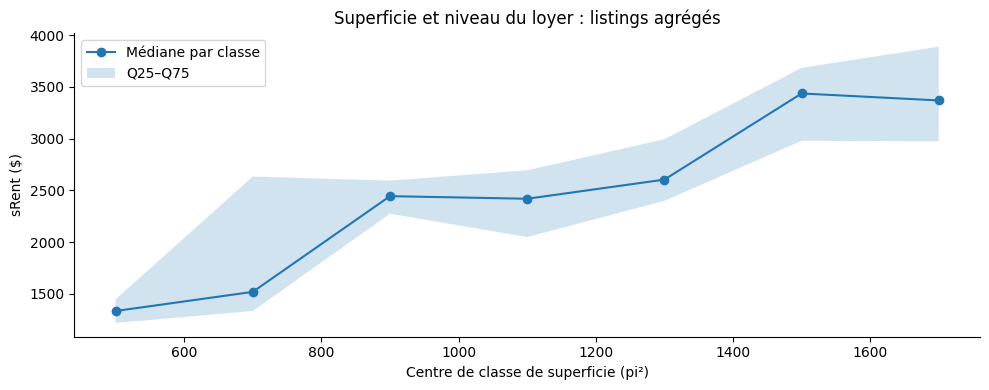

**Interprétation descriptive.** Une association globale peut refléter la composition par bâtiment et par type d’unité. Les classes ont des effectifs différents, indiqués dans le tableau. Aucun coefficient de cette section n’explique une croissance same-unit, dont la cible n’existe pas encore.

In [6]:
relations = []
for feature in ['sSqft', 'sBeds', 'sBaths', 'sFloor']:
    relations.append({'caractéristique': feature,
                      'Pearson avec sRent': listings[feature].corr(listings['sRent']),
                      'Spearman avec sRent': listings[feature].corr(listings['sRent'], method='spearman')})
display(pd.DataFrame(relations).set_index('caractéristique').round(3))
for col in ['sPropCode', 'sBuilding', 'sState', 'sCity', 'sBeds', 'sBaths', 'sFloor', 'sUnitType', 'sUnitSubtype']:
    display(Markdown(f'**Niveau de loyer des listings par {col}**'))
    display(stats(listings, [col], ['sRent', 'sSqft']))
area_bins = np.arange(400, 2201, 200)
area_summary = listings.assign(classe_superficie=pd.cut(listings['sSqft'], area_bins, right=False)).groupby(
    'classe_superficie', observed=True)['sRent'].agg(effectif='size', moyenne='mean', médiane='median',
                                                   Q25=lambda x:x.quantile(.25), Q75=lambda x:x.quantile(.75))
display(area_summary.round(2))
fig, ax = plt.subplots(figsize=(10,4))
area_summary = area_summary.copy()
area_summary.loc[area_summary['effectif'].lt(MIN_DISPLAY), ['moyenne','médiane','Q25','Q75']] = np.nan
x = np.array([i.mid for i in area_summary.index])
ax.plot(x, area_summary['médiane'], marker='o', label='Médiane par classe')
ax.fill_between(x, area_summary['Q25'], area_summary['Q75'], alpha=.2, label='Q25–Q75')
ax.set(title='Superficie et niveau du loyer : listings agrégés', xlabel='Centre de classe de superficie (pi²)', ylabel='sRent ($)')
ax.legend(); plt.tight_layout(); plt.show()
note('Une association globale peut refléter la composition par bâtiment et par type d’unité. Les classes ont des effectifs différents, indiqués dans le tableau. Aucun coefficient de cette section n’explique une croissance same-unit, dont la cible n’existe pas encore.')

## 6. Renouvellements et relocations : première comparaison

Selon le starter, `sRenewal = 1` désigne un renouvellement et `sRenewal = 0` une relocation. Les différences ci-dessous portent sur les niveaux et concessions observés, sans appariement d’unités ni contrôle de composition. Les tableaux croisés par année, province et propriété permettent de repérer des déséquilibres de couverture.

,observations,contractuel_moyen,contractuel_médian,effectif_moyen,effectif_médian,part avec concession (%),écart_relatif_moyen
sRenewal,,,,,,,
0,2337,1978.80,1930.0,1880.93,1870.0,62.26,4.58
1,1965,2023.45,2005.0,1915.93,1925.0,64.33,4.95


observations  contractuel_moyen  contractuel_médian  \
année sRenewal                                                        
2017  0                   91            1730.11              1810.0   
      1                    2                NaN                 NaN   
2018  0                  121            1451.74              1440.0   
      1                   51            1816.76              1875.0   
2019  0                  231            1645.87              1725.0   
      1                   97            1636.19              1735.0   
2020  0                  172            1676.37              1755.0   
      1                  201            1725.35              1805.0   
2021  0                  136            1771.32              1785.0   
      1                  225            1787.33              1885.0   
2022  0                  190            1796.00              1730.0   
      1                  232            1920.58              2000.0   
2023  0                  447            2155.97              2165.0   
      1                  246            1961.38              2042.5   
2024  0                  474            2155.96              2230.0   
      1                  428            2181.94              2207.5   
2025  0                  475            2221.13              2285.0   
      1                  483            2297.41              2365.0   

                effectif_moyen  effectif_médian  part avec concession (%)  \
année sRenewal                                                              
2017  0                1710.13          1800.00                     38.46   
      1                    NaN              NaN                       NaN   
2018  0                1433.67          1411.17                     36.36   
      1                1788.40          1870.00                     43.14   
2019  0                1618.47          1695.00                     42.42   
      1                1605.74          1691.36                     48.45   
2020  0                1640.24          1707.02                     50.00   
      1                1691.38          1749.30                     47.76   
2021  0                1724.21          1761.71                     54.41   
      1                1738.71          1790.57                     53.78   
2022  0                1738.83          1700.75                     54.21   
      1                1852.13          1898.56                     59.91   
2023  0                2071.04          2076.79                     57.94   
      1                1898.22          1954.80                     47.56   
2024  0                2025.15          2087.17                     77.22   
      1                2061.38          2081.36                     68.46   
2025  0                2021.29          2060.47                     82.11   
      1                2077.91          2144.28                     88.61   

                écart_relatif_moyen  
année sRenewal                       
2017  0                        1.17  
      1                         NaN  
2018  0                        1.27  
      1                        1.57  
2019  0                        1.64  
      1                        1.85  
2020  0                        2.13  
      1                        2.05  
2021  0                        2.65  
      1                        2.71  
2022  0                        3.10  
      1                        3.51  
2023  0                        3.81  
      1                        3.16  
2024  0                        6.03  
      1                        5.35  
2025  0                        8.81  
      1                        9.45

observations  contractuel_moyen  contractuel_médian  \
sState  sRenewal                                                        
Ontario 0                  221            3226.24              2790.0   
        1                  131            3163.78              2760.0   
Quebec  0                 2116            1848.51              1845.0   
        1                 1834            1942.00              1957.5   

                  effectif_moyen  effectif_médian  part avec concession (%)  \
sState  sRenewal                                                              
Ontario 0                3015.58          2653.00                     79.19   
        1                2891.13          2531.05                     92.37   
Quebec  0                1762.43          1781.05                     60.49   
        1                1846.27          1880.20                     62.32   

                  écart_relatif_moyen  
sState  sRenewal                       
Ontario 0                        6.33  
        1                        8.53  
Quebec  0                        4.39  
        1                        4.70

observations  contractuel_moyen  contractuel_médian  \
sPropCode sRenewal                                                        
carlyle   0                  320            2060.97              2277.5   
          1                  215            2249.95              2450.0   
dj1       0                  183            2078.83              1980.0   
          1                  208            2206.25              2177.5   
dj2       0                  166            1817.23              1512.5   
          1                  125            1935.52              1555.0   
levesque  0                  319            1432.41              1480.0   
          1                  322            1515.64              1565.0   
metcalfe  0                  221            3226.24              2790.0   
          1                  131            3163.78              2760.0   
stelz1    0                  386            1846.80              1927.5   
          1                  455            1968.88              2025.0   
stelz2    0                  391            1796.75              1885.0   
          1                  424            1914.20              2020.0   
stelz3    0                  133            1938.65              2155.0   
          1                    1                NaN                 NaN   
wsp1      0                  218            2016.88              2215.0   
          1                   84            2144.82              2355.0   

                    effectif_moyen  effectif_médian  part avec concession (%)  \
sPropCode sRenewal                                                              
carlyle   0                1933.30          2147.02                     74.69   
          1                2062.75          2232.98                     86.05   
dj1       0                2008.30          1915.00                     48.09   
          1                2106.59          2056.07                     58.17   
dj2       0                1735.52          1438.34                     54.82   
          1                1830.48          1451.69                     58.40   
levesque  0                1388.19          1444.61                     48.59   
          1                1450.84          1505.82                     61.18   
metcalfe  0                3015.58          2653.00                     79.19   
          1                2891.13          2531.05                     92.37   
stelz1    0                1796.01          1884.24                     51.04   
          1                1907.40          1989.02                     51.43   
stelz2    0                1731.47          1835.92                     56.27   
          1                1830.04          1931.78                     60.14   
stelz3    0                1781.84          1922.76                     75.94   
          1                    NaN              NaN                       NaN   
wsp1      0                1857.57          2043.73                     86.70   
          1                1945.11          2144.66                     91.67   

                    écart_relatif_moyen  
sPropCode sRenewal                       
carlyle   0                        6.04  
          1                        8.21  
dj1       0                        3.23  
          1                        4.39  
dj2       0                        4.30  
          1                        5.19  
levesque  0                        2.87  
          1                        4.07  
metcalfe  0                        6.33  
          1                        8.53  
stelz1    0                        2.63  
          1                        2.97  
stelz2    0                        3.44  
          1                        4.30  
stelz3    0                        8.11  
          1                         NaN  
wsp1      0                        7.82  
          1                        9.43

**Répartition des baux par année et sState (effectifs)**

sRenewal       Relocation (0)  Renouvellement (1)
année sState                                     
2017  Quebec               91                   2
2018  Quebec              121                  51
2019  Quebec              231                  97
2020  Quebec              172                 201
2021  Quebec              136                 225
2022  Quebec              190                 232
2023  Ontario             104                   0
      Quebec              343                 246
2024  Ontario              61                  67
      Quebec              413                 361
2025  Ontario              56                  64
      Quebec              419                 419

**Répartition des baux par année et sPropCode (effectifs)**

sRenewal         Relocation (0)  Renouvellement (1)
année sPropCode                                    
2017  stelz1                 91                   2
2018  levesque               64                   0
      stelz1                 57                  51
2019  dj1                    48                   0
      levesque               51                  31
      stelz1                 38                  65
      stelz2                 94                   1
2020  dj1                    32                  25
      levesque               33                  52
      stelz1                 34                  70
      stelz2                 73                  54
2021  dj1                    21                  36
      levesque               31                  53
      stelz1                 41                  60
      stelz2                 43                  76
2022  dj1                    19                  36
      dj2                    63                   2
      levesque               31                  51
      stelz1                 36                  65
      stelz2                 41                  78
2023  carlyle               153                   2
      dj1                    22                  35
      dj2                    35                  42
      levesque               41                  42
      metcalfe              104                   0
      stelz1                 34                  65
      stelz2                 58                  60
2024  carlyle                97                  98
      dj1                    19                  39
      dj2                    35                  43
      levesque               39                  45
      metcalfe               61                  67
      stelz1                 40                  56
      stelz2                 44                  75
      wsp1                  139                   5
2025  carlyle                70                 115
      dj1                    22                  37
      dj2                    33                  38
      levesque               29                  48
      metcalfe               56                  64
      stelz1                 15                  21
      stelz2                 38                  80
      stelz3                133                   1
      wsp1                   79                  79

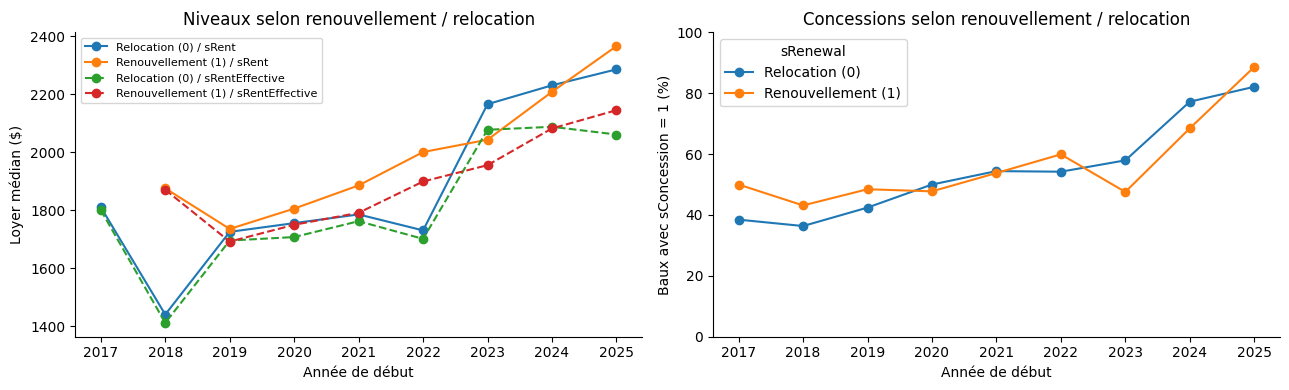

**Interprétation descriptive.** Les écarts entre groupes peuvent refléter les bâtiments, les caractéristiques des unités et les années représentées. Ils ne mesurent pas l’effet causal d’un renouvellement et ne fixent pas la méthodologie future.

In [7]:
renewal_labels = {0: 'Relocation (0)', 1: 'Renouvellement (1)'}
for groups in [['sRenewal'], ['année','sRenewal'], ['sState','sRenewal'], ['sPropCode','sRenewal']]:
    table = leases.groupby(groups, observed=True).agg(
        observations=('sRent','size'), contractuel_moyen=('sRent','mean'), contractuel_médian=('sRent','median'),
        effectif_moyen=('sRentEffective','mean'), effectif_médian=('sRentEffective','median'),
        part_concession=('sConcession', lambda x:x.eq(1).mean()*100), écart_relatif_moyen=('écart (%)','mean'))
    display(table.rename(columns={'part_concession':'part avec concession (%)'}).round(2))
for col in ['sState', 'sPropCode']:
    mix = pd.crosstab([leases['année'], leases[col]], leases['sRenewal'])
    display(Markdown(f'**Répartition des baux par année et {col} (effectifs)**'))
    display(mix.rename(columns=renewal_labels))
fig, axes = plt.subplots(1,2,figsize=(13,4))
for price, linestyle in [('sRent','-'),('sRentEffective','--')]:
    med = leases.groupby(['année','sRenewal'])[price].median().where(leases.groupby(['année','sRenewal']).size().ge(MIN_DISPLAY)).unstack()
    for renewal in med:
        axes[0].plot(med.index, med[renewal], linestyle=linestyle, marker='o',
                     label=f'{renewal_labels.get(renewal, renewal)} / {price}')
leases.groupby(['année','sRenewal'])['sConcession'].agg(lambda x:x.eq(1).mean()*100).unstack().rename(
    columns=renewal_labels).plot(ax=axes[1], marker='o')
axes[0].set(title='Niveaux selon renouvellement / relocation', xlabel='Année de début', ylabel='Loyer médian ($)')
axes[1].set(title='Concessions selon renouvellement / relocation', xlabel='Année de début', ylabel='Baux avec sConcession = 1 (%)', ylim=(0,100))
axes[0].legend(fontsize=8); plt.tight_layout(); plt.show()
note('Les écarts entre groupes peuvent refléter les bâtiments, les caractéristiques des unités et les années représentées. Ils ne mesurent pas l’effet causal d’un renouvellement et ne fixent pas la méthodologie future.')

## 7. Concessions : évolution des catégories et périodes enregistrées

Les concessions sont regroupées selon leur **date de début**, sans les affecter à un bail : aucune clé de concession/bail unique n’est établie ici. Les lignes ne représentent pas nécessairement des concessions indépendantes, et les sommes de `sAmount` ne sont pas assimilées à un coût annuel ni à une réduction mensuelle de loyer. Les dates futures observées à l’audit sont présentées séparément.

Le starter avertit que `PromoPay` n’est pas une charge mensuelle récurrente. Les valeurs de `sMonths` sont décrites, sans décider de leur étalement ni reconstruire `sRentEffective`.

In [8]:
concession_summary = concessions.groupby(['année','sChargeCode'], observed=True).agg(
    lignes=('sAmount','size'), montant_moyen=('sAmount','mean'), montant_médian=('sAmount','median'),
    mois_médians=('sMonths','median'), part_un_mois=('sMonths', lambda x:x.eq(1).mean()*100))
display(concession_summary.rename(columns={'part_un_mois':'part avec sMonths = 1 (%)'}).round(2))
display(pd.crosstab(concessions['sChargeCode'], concessions['sMonths']).rename_axis(
    index='Code de concession', columns='sMonths (valeur enregistrée)'))
future_concessions = concessions[~concessions['année'].isin(YEARS)]
print('Lignes de concessions hors fenêtre des débuts de bail 2017–2025 :', len(future_concessions))
promo = concessions.loc[concessions['sChargeCode'].eq('PromoPay')]
print('PromoPay : part des lignes avec sMonths = 1 (%) :', round(promo['sMonths'].eq(1).mean()*100,2))
note('Les catégories accessoires (stationnement, casiers, etc.) doivent rester distinguées des rabais sur le loyer. Les dates de début futures ne constituent pas des observations réalisées de loyers futurs. Aucune répartition mensuelle n’est appliquée.')

lignes  montant_moyen  montant_médian  mois_médians  \
année sChargeCode                                                        
2017  Freeothe          7         -71.82          -67.50           6.0   
      PromoPay          6       -1432.27        -1700.00           1.0   
      freelock          4            NaN             NaN           NaN   
      freepark         16         -56.31          -52.58          12.0   
      freerent          1            NaN             NaN           NaN   
2018  Freeothe         11         -78.58          -58.79          12.0   
      Indem             2            NaN             NaN           NaN   
      PromoPay         24        -704.24         -499.44           1.0   
      Referenc          2            NaN             NaN           NaN   
      freeappl          1            NaN             NaN           NaN   
      freelock          6         -44.28          -48.56          12.0   
      freepark         19        -115.86          -64.26           6.0   
      freerent          5         -49.18          -17.66          12.0   
2019  Freeothe         26         -60.31          -41.22          12.0   
      Indem             3            NaN             NaN           NaN   
      PromoPay         50        -988.99         -796.62           1.0   
      Referenc          2            NaN             NaN           NaN   
      freeappl          2            NaN             NaN           NaN   
      freelock         11         -78.89          -68.64          12.0   
      freepark         41         -92.45          -83.18          12.0   
      freerent          7         -61.38          -61.00          12.0   
2020  Freeothe         37         -96.12          -70.17          12.0   
      Indem             6        -114.24          -85.04          12.0   
      PromoPay         94        -835.92         -706.62           1.0   
      Referenc          2            NaN             NaN           NaN   
      freeappl          2            NaN             NaN           NaN   
      freelock          9        -127.07          -72.50           6.0   
      freepark         62         -75.63          -69.70          12.0   
      freerent         12         -85.20          -68.65          12.0   
2021  Freeothe         42        -124.44          -99.07          12.0   
      Indem             5         -98.37          -50.19           6.0   
      PromoPay        116        -868.24         -811.05           1.0   
      Referenc          1            NaN             NaN           NaN   
      freeappl          4            NaN             NaN           NaN   
      freelock         10         -74.05          -53.10          12.0   
      freepark         60        -103.26          -84.78          12.0   
      freerent          8         -82.39          -51.46          12.0   
2022  Freeothe         51        -163.61         -112.14          12.0   
      Indem             5        -213.44         -106.50          12.0   
      PromoPay        120       -1105.63        -1100.50           1.0   
      Referenc          2            NaN             NaN           NaN   
      freeappl          2            NaN             NaN           NaN   
      freelock         11        -146.24         -118.59          12.0   
      freepark         94        -149.11         -131.68          12.0   
      freerent         13         -89.54          -59.14          12.0   
2023  Freeothe         63        -203.07         -155.40          12.0   
      Indem             7        -193.66          -57.66          12.0   
      PromoPay        173       -1430.94        -1282.08           1.0   
      Referenc          4            NaN             NaN           NaN   
      freeappl          2            NaN             NaN           NaN   
      freelock         34        -147.61         -141.50          12.0   
      freepark        144        -180.66         -135.20          12.0   
      freerent         

sMonths (valeur enregistrée),1.0,2.0,3.0,5.0,6.0,12.0,17.0,23.0
Code de concession,,,,,,,,
Freeothe,0,0,75,14,158,323,0,0
Indem,0,0,9,4,17,38,1,0
PromoPay,1318,176,0,0,0,0,0,0
Referenc,0,0,4,1,7,23,1,0
freeappl,0,0,2,0,14,28,0,0
freelock,0,0,22,3,51,99,0,0
freepark,0,0,153,12,276,559,3,3
freerent,0,0,23,3,38,102,0,0


Lignes de concessions hors fenêtre des débuts de bail 2017–2025 : 316
PromoPay : part des lignes avec sMonths = 1 (%) : 88.22


**Interprétation descriptive.** Les catégories accessoires (stationnement, casiers, etc.) doivent rester distinguées des rabais sur le loyer. Les dates de début futures ne constituent pas des observations réalisées de loyers futurs. Aucune répartition mensuelle n’est appliquée.

## 8. Historique des loyers demandés et comparaison prudente

L’audit a déjà établi l’alignement au premier du mois et les lacunes par unité : aucun mois n’est interpolé. Les tableaux montrent la couverture annuelle, les niveaux par segment et la part des bâtiments dans les observations disponibles.

La comparaison avec les baux est limitée aux **mêmes cellules année / bâtiment / chambres** lorsqu’elles sont présentes dans les deux sources. Chaque cellule affiche les effectifs des deux sources ; elle ne constitue ni un appariement temporel de baux ni une comparaison same-unit. Les unités et les mois au sein d’une cellule peuvent différer. Les différences de médianes ne sont donc pas interprétées comme primes à la relocation ou décotes.

,observations,propriétés,bâtiments,unités distinctes
année,,,,
2016,16,1.0,1.0,15.0
2017,118,2.0,2.0,92.0
2018,205,4.0,3.0,158.0
2019,328,4.0,3.0,260.0
2020,303,4.0,3.0,250.0
2021,290,5.0,3.0,236.0
2022,392,7.0,5.0,327.0
2023,663,8.0,6.0,550.0
2024,773,9.0,6.0,630.0


**Loyers demandés par année et sPropCode**

sAskingRent                                   
                   effectif  moyenne médiane      Q25      Q75
année sPropCode                                               
2016  stelz1             16  1715.00  1915.0  1598.75  1983.75
2017  levesque           10  1309.50  1392.5  1310.00  1560.00
      stelz1            108  1789.12  1857.5  1693.75  1992.50
2018  dj1                11  1851.36  1875.0  1230.00  2470.00
      levesque           81  1296.91  1395.0  1265.00  1495.00
      stelz1            101  1775.25  1910.0  1680.00  2035.00
      stelz2             12  1673.33  1842.5  1376.25  1967.50
2019  dj1                56  1869.29  1850.0  1312.50  2357.50
      levesque           68  1392.21  1422.5  1317.50  1581.25
      stelz1             86  1824.30  1955.0  1535.00  2142.50
      stelz2            118  1709.45  1830.0  1606.25  1930.00
2020  dj1                46  2115.22  2087.5  1471.25  2597.50
      levesque           67  1361.64  1420.0  1300.00  1557.50
      stelz1             81  1916.11  2020.0  1860.00  2160.00
      stelz2            109  1738.12  1875.0  1615.00  2005.00
2021  dj1                50  2211.00  2185.0  1567.50  2773.75
      dj2                14  2048.21  1947.5  1255.00  2647.50
      levesque           57  1527.02  1530.0  1410.00  1650.00
      stelz1             75  2039.20  2100.0  1910.00  2297.50
      stelz2             94  1805.32  1950.0  1651.25  2100.00
2022  carlyle            25  1829.20  1450.0  1190.00  2430.00
      dj1                49  2155.82  2090.0  1515.00  2760.00
      dj2                74  1839.73  1532.5  1197.50  2501.25
      levesque           66  1474.32  1537.5  1430.00  1726.25
      metcalfe           11  3262.27  2770.0  2532.50  3535.00
      stelz1             79  2028.54  2185.0  1335.00  2415.00
      stelz2             88  1937.67  2082.5  1771.25  2230.00
2023  carlyle           180  2034.17  2242.5  1265.00  2612.50
      dj1                34  2052.06  2075.0  1526.25  2302.50
      dj2                66  1803.41  1320.0  1181.25  2541.25
      levesque           69  1542.97  1640.0  1455.00  1755.00
      metcalfe          118  3157.71  2752.5  2375.00  4013.75
      stelz1             80  2101.50  2220.0  1817.50  2466.25
      stelz2            100  1940.40  2040.0  1836.25  2255.00
      wsp1               16  2084.38  2282.5  1572.50  2485.00
2024  carlyle           156  2150.61  2362.5  1333.75  2763.75
      dj1                44  2460.45  2407.5  1736.25  3113.75
      dj2                61  1820.16  1405.0  1210.00  2565.00
      levesque           64  1634.45  1680.0  1563.75  1810.00
      metcalfe          102  3264.85  2885.0  2456.25  4033.75
      stelz1             70  2122.79  2275.0  1940.00  2463.75
      stelz2             95  2041.68  2135.0  1890.00  2350.00
      stelz3             15  2185.67  2460.0  1860.00  2545.00
      wsp1              166  2013.73  2247.5  1308.75  2495.00
2025  carlyle           134  2374.74  2602.5  1476.25  2945.00
      dj1                40  2544.62  2465.0  1871.25  3250.00
      dj2                57  1915.44  1505.0  1355.00  2350.00
      levesque           54  1794.91  1925.0  1702.50  2065.00
      metcalfe           97  3472.78  3010.0  2570.00  4415.00
      stelz1             30  2338.83  2462.5  2125.00  2645.00
      stelz2             80  2150.12  2265.0  1937.50  2510.00
      stelz3            147  1953.95  2165.0  1312.50  2417.50
      wsp1              130  2170.15  2410.0  1377.50  2678.75

**Loyers demandés par année et sBuilding**

sAskingRent                                   
                        effectif  moyenne médiane      Q25      Q75
année sBuilding                                                    
2016  Saint-Elzear            16  1715.00  1915.0  1598.75  1983.75
2017  Levesque                10  1309.50  1392.5  1310.00  1560.00
      Saint-Elzear           108  1789.12  1857.5  1693.75  1992.50
2018  Daniel-Johnson          11  1851.36  1875.0  1230.00  2470.00
      Levesque                81  1296.91  1395.0  1265.00  1495.00
      Saint-Elzear           113  1764.42  1910.0  1665.00  2030.00
2019  Daniel-Johnson          56  1869.29  1850.0  1312.50  2357.50
      Levesque                68  1392.21  1422.5  1317.50  1581.25
      Saint-Elzear           204  1757.87  1865.0  1602.50  2026.25
2020  Daniel-Johnson          46  2115.22  2087.5  1471.25  2597.50
      Levesque                67  1361.64  1420.0  1300.00  1557.50
      Saint-Elzear           190  1814.00  1955.0  1696.25  2060.00
2021  Daniel-Johnson          64  2175.39  2185.0  1517.50  2771.25
      Levesque                57  1527.02  1530.0  1410.00  1650.00
      Saint-Elzear           169  1909.11  2005.0  1785.00  2175.00
2022  Daniel-Johnson         123  1965.65  1820.0  1295.00  2550.00
      Le Carlyle              25  1829.20  1450.0  1190.00  2430.00
      Levesque                66  1474.32  1537.5  1430.00  1726.25
      Saint-Elzear           167  1980.66  2125.0  1670.00  2312.50
      The Met                 11  3262.27  2770.0  2532.50  3535.00
2023  Daniel-Johnson         100  1887.95  1642.5  1230.00  2488.75
      Le Carlyle             180  2034.17  2242.5  1265.00  2612.50
      Levesque                69  1542.97  1640.0  1455.00  1755.00
      Saint-Elzear           180  2012.00  2097.5  1825.00  2317.50
      The Met                118  3157.71  2752.5  2375.00  4013.75
      Westpark                16  2084.38  2282.5  1572.50  2485.00
2024  Daniel-Johnson         105  2088.48  1835.0  1345.00  2760.00
      Le Carlyle             156  2150.61  2362.5  1333.75  2763.75
      Levesque                64  1634.45  1680.0  1563.75  1810.00
      Saint-Elzear           180  2085.22  2190.0  1890.00  2426.25
      The Met                102  3264.85  2885.0  2456.25  4033.75
      Westpark               166  2013.73  2247.5  1308.75  2495.00
2025  Daniel-Johnson          97  2174.90  1880.0  1410.00  2915.00
      Le Carlyle             134  2374.74  2602.5  1476.25  2945.00
      Levesque                54  1794.91  1925.0  1702.50  2065.00
      Saint-Elzear           257  2059.94  2250.0  1370.00  2470.00
      The Met                 97  3472.78  3010.0  2570.00  4415.00
      Westpark               130  2170.15  2410.0  1377.50  2678.75

...

sAskingRent                                   
                 effectif  moyenne médiane      Q25      Q75
année sState                                                
2016  Quebec           16  1715.00  1915.0  1598.75  1983.75
2017  Quebec          118  1748.47  1825.0  1625.00  1977.50
2018  Quebec          205  1584.37  1545.0  1280.00  1955.00
2019  Quebec          328  1701.08  1772.5  1358.75  1991.25
2020  Quebec          303  1759.70  1845.0  1382.50  2055.00
2021  Quebec          290  1892.78  1950.0  1521.25  2190.00
2022  Ontario          11  3262.27  2770.0  2532.50  3535.00
      Quebec          381  1878.16  1870.0  1335.00  2305.00
2023  Ontario         118  3157.71  2752.5  2375.00  4013.75
      Quebec          545  1939.30  2010.0  1345.00  2405.00
2024  Ontario         102  3264.85  2885.0  2456.25  4033.75
      Quebec          671  2040.25  2135.0  1392.50  2517.50
2025  Ontario          97  3472.78  3010.0  2570.00  4415.00
      Quebec          672  2139.33  2217.5  1435.00  2626.25

**Loyers demandés par année et sBeds**

sAskingRent                                   
               effectif  moyenne médiane      Q25      Q75
année sBeds                                               
2016  1               4      NaN     NaN      NaN      NaN
      2              12  1938.33  1955.0  1870.00  2012.50
2017  1              20  1047.50  1087.5  1022.50  1140.00
      2              94  1869.26  1870.0  1756.25  1988.75
      3               4      NaN     NaN      NaN      NaN
2018  1              44   925.23   910.0   685.00  1125.00
      2             153  1731.14  1725.0  1455.00  1975.00
      3               8  2402.50  2282.5  2160.00  2526.25
2019  1              74  1084.80  1102.5   958.75  1210.00
      2             245  1854.45  1860.0  1620.00  2030.00
      3               9  2593.33  2380.0  2260.00  3025.00
2020  1              62  1073.47  1085.0   961.25  1223.75
      2             236  1917.01  1955.0  1677.50  2081.25
      3               5  2844.00  3170.0  2415.00  3285.00
2021  0               1      NaN     NaN      NaN      NaN
      1              51  1195.00  1170.0  1077.50  1330.00
      2             233  2025.88  2020.0  1755.00  2205.00
      3               5  2944.00  3190.0  2385.00  3350.00
2022  0              17  1373.82  1190.0  1090.00  1270.00
      1             119  1302.73  1220.0  1115.00  1400.00
      2             247  2205.28  2185.0  1870.00  2415.00
      3               9  3153.33  3265.0  2725.00  3560.00
2023  0              47  2232.87  2315.0  1670.00  2715.00
      1             213  1505.49  1290.0  1175.00  1665.00
      2             392  2476.33  2305.0  2020.00  2670.00
      3              11  3017.73  2920.0  2665.00  3477.50
2024  0              41  2177.93  2310.0  1360.00  2855.00
      1             260  1519.02  1335.0  1200.00  1586.25
      2             461  2571.01  2440.0  2165.00  2755.00
      3              11  2959.09  2975.0  2727.50  3220.00
2025  0              40  2576.62  2665.0  2413.75  3008.75
      1             267  1548.15  1360.0  1260.00  1577.50
      2             450  2709.30  2530.0  2277.50  2900.00
      3              12  3240.42  3145.0  2952.50  3521.25

observations_demandées  demandé_médian  \
année sBuilding      sBeds                                           
2017  Saint-Elzear   1                          18          1100.0   
                     2                          86          1897.5   
                     3                           4             NaN   
2018  Levesque       1                          14           660.0   
                     2                          66          1415.0   
                     3                           1             NaN   
      Saint-Elzear   1                          25          1010.0   
                     2                          81          1940.0   
                     3                           7             NaN   
2019  Daniel-Johnson 1                          24          1290.0   
                     2                          30          2175.0   
                     3                           2             NaN   
      Levesque       1                           8           695.0   
                     2                          58          1457.5   
                     3                           2             NaN   
      Saint-Elzear   1                          42          1070.0   
                     2                         157          1920.0   
                     3                           5             NaN   
2020  Daniel-Johnson 1                          14          1300.0   
                     2                          29          2305.0   
                     3                           3             NaN   
      Levesque       1                          10           675.0   
                     2                          56          1475.0   
                     3                           1             NaN   
      Saint-Elzear   1                          38          1072.5   
                     2                         151          2000.0   
                     3                           1             NaN   
2021  Daniel-Johnson 1                          20          1372.5   
                     2                          40          2450.0   
                     3                           3             NaN   
      Levesque       1                           3             NaN   
                     2                          52          1542.5   
                     3                           2             NaN   
      Saint-Elzear   1                          28          1112.5   
                     2                         141          2065.0   
2022  Daniel-Johnson 0                          15          1190.0   
                     1                          49          1365.0   
                     2                          55          2540.0   
                     3                           4             NaN   
      Levesque       1                          12           775.0   
                     2                          53          1630.0   
                     3                           1             NaN   
      Saint-Elzear   1                          39          1170.0   
                     2                         124          2195.0   
                     3                           4             NaN   
2023  Daniel-Johnson 0                          12          1152.5   
                     1                          42          1300.0   
                     2                          43          2500.0   
                     3                           3             NaN   
      Le Carlyle     1                          73          1245.0   
                     2                         103          2520.0   
                     3                           4             NaN   
      Levesque       1                          10           780.0   
                     2                          58          1655.0   
                     3                           1             NaN   
      Saint-Elzear   1                

Cellules communes année/bâtiment/chambres : 98
Cellules de loyers demandés sans baux correspondants : 12


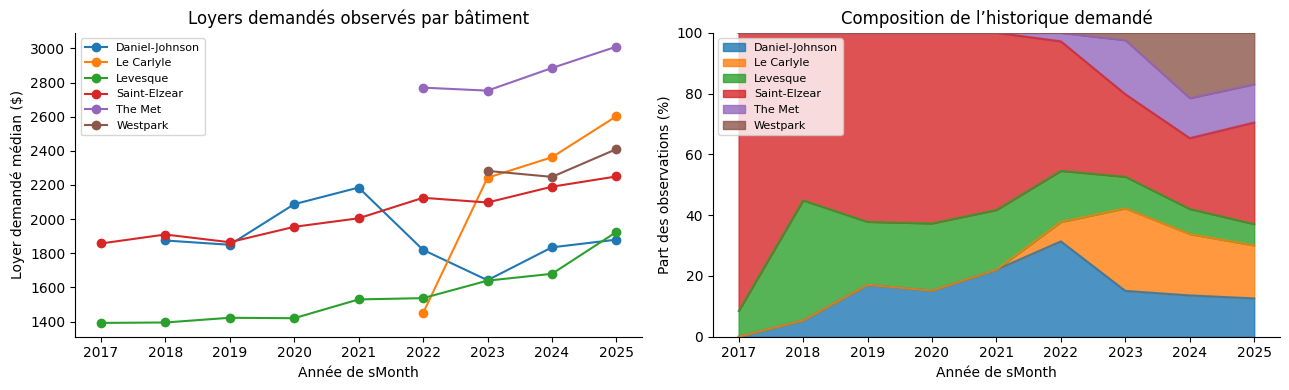

**Interprétation descriptive.** L’évolution demandée reflète aussi le mix des observations disponibles. Même la comparaison par cellules communes ne garantit pas les mêmes unités ou dates ; elle reste un repère descriptif, sans conversion entre mesures de loyer.

In [9]:
asking_coverage = asking.groupby('année').agg(observations=('sAskingRent','size'),
    propriétés=('sPropCode','nunique'), bâtiments=('hBuilding','nunique'))
asking_units = asking.groupby('année').apply(lambda d: d[list(UNIT_KEY)].drop_duplicates().shape[0], include_groups=False)
asking_coverage['unités distinctes'] = asking_units
display(asking_coverage)
for col in ['sPropCode', 'sBuilding', 'sState', 'sBeds']:
    display(Markdown(f'**Loyers demandés par année et {col}**'))
    display(stats(asking, ['année',col], ['sAskingRent']))
cell_keys = ['année','sBuilding','sBeds']
asking_cells = asking_window.groupby(cell_keys).agg(
    observations_demandées=('sAskingRent','size'), demandé_médian=('sAskingRent','median'))
lease_cells = leases.groupby(cell_keys).agg(observations_baux=('sRent','size'),
    contractuel_médian=('sRent','median'), effectif_médian=('sRentEffective','median'))
comparison = asking_cells.join(lease_cells, how='inner')
comparison['différence demandé − contractuel ($)'] = comparison['demandé_médian']-comparison['contractuel_médian']
comparison['différence demandé − effectif ($)'] = comparison['demandé_médian']-comparison['effectif_médian']
display(comparison.round(2))
print('Cellules communes année/bâtiment/chambres :', len(comparison))
print('Cellules de loyers demandés sans baux correspondants :', len(asking_cells.index.difference(lease_cells.index)))
fig, axes = plt.subplots(1,2,figsize=(13,4))
asking_window.groupby(['année','sBuilding'])['sAskingRent'].median().where(asking_window.groupby(['année','sBuilding']).size().ge(MIN_DISPLAY)).unstack().plot(ax=axes[0], marker='o')
shares(asking_window, 'sBuilding').plot.area(ax=axes[1], alpha=.8)
axes[0].set(title='Loyers demandés observés par bâtiment', xlabel='Année de sMonth', ylabel='Loyer demandé médian ($)')
axes[1].set(title='Composition de l’historique demandé', xlabel='Année de sMonth', ylabel='Part des observations (%)', ylim=(0,100))
axes[0].legend(fontsize=8); axes[1].legend(fontsize=8)
plt.tight_layout(); plt.show()
note('L’évolution demandée reflète aussi le mix des observations disponibles. Même la comparaison par cellules communes ne garantit pas les mêmes unités ou dates ; elle reste un repère descriptif, sans conversion entre mesures de loyer.')

## 9. Contrôles de fin d’exécution

Les empreintes des quatre CSV, du starter et de l’audit doivent rester identiques. Ce notebook ne contient aucune instruction d’export de données ni d’enregistrement externe de graphique ; les seules sorties persistantes sont des tableaux agrégés et graphiques intégrés au notebook.

In [10]:
assert all(hashlib.sha256(p.read_bytes()).hexdigest() == digest for p, digest in before_hashes.items())
print('CSV bruts, starter et audit inchangés. Aucun modèle, nettoyage, interpolation ou export individuel effectué.')

CSV bruts, starter et audit inchangés. Aucun modèle, nettoyage, interpolation ou export individuel effectué.


La cellule suivante formule les constats à partir des seuls agrégats calculés ci-dessus.

In [11]:
f = []
f.append(f"L’extrait relie {mapping['sPropCode'].nunique()} codes de propriété à {mapping['hBuilding'].nunique()} identifiants de bâtiment. Premières années de bail observées : " + '; '.join(f'{b} : {int(y)}' for b,y in first_building.items()) + '.')
f.append(f"Entre 2021 et 2024, la médiane contractuelle passe de {annual.loc[2021,('sRent','médiane')]:.2f} $ à {annual.loc[2024,('sRent','médiane')]:.2f} $. La superficie médiane passe de {historical_mix.loc[2021,'superficie_médiane']:.0f} à {historical_mix.loc[2024,'superficie_médiane']:.0f} pi², et la part des baux à 2 chambres ou plus de {historical_mix.loc[2021,'part 2 chambres et plus (%)']:.2f} % à {historical_mix.loc[2024,'part 2 chambres et plus (%)']:.2f} %.")
f.append(f"Écart moyen contractuel 2024 − 2021 : {total_change:.2f} $. Contributions descriptives : couverture des bâtiments {coverage_effect:.2f} $, parts des bâtiments communs {part_effect:.2f} $, niveaux des bâtiments communs {level_effect:.2f} $. Ce dernier terme n’est pas une croissance same-unit.")
f.append(f"Variation brute de médiane contractuelle en 2023 : {level_changes.loc[2023,'sRent']:.2f} %. Elle mélange composition et évolution des niveaux.")
f.append(f"Corrélation sRent / sRentEffective : {correlation:.4f}. Écart relatif moyen : {gap_annual.loc[2021,'écart_relatif_moyen']:.2f} % en 2021 et {gap_annual.loc[2025,'écart_relatif_moyen']:.2f} % en 2025 ; les champs ne sont pas interchangeables.")
f.append(f"Part de baux avec sConcession = 1 : {gap_annual.loc[2021,'part_avec_concession']:.2f} % en 2021 et {gap_annual.loc[2025,'part_avec_concession']:.2f} % en 2025. Parmi les lignes PromoPay, {promo['sMonths'].eq(1).mean()*100:.2f} % ont sMonths = 1 ; aucune mensualisation n’est effectuée.")
for renewal, label in renewal_labels.items():
    d = leases[(leases['année']==2025) & (leases['sRenewal']==renewal)]
    f.append(f"2025 — {label} : {len(d)} baux ; médianes contractuelle {d['sRent'].median():.2f} $ et effective {d['sRentEffective'].median():.2f} $ ; {d['sConcession'].eq(1).mean()*100:.2f} % avec concession. Comparaison de niveaux, sans contrôle du mix.")
f.append(f"Association superficie / sRent dans les listings : Pearson {listings['sSqft'].corr(listings['sRent']):.3f}, Spearman {listings['sSqft'].corr(listings['sRent'],method='spearman'):.3f}. Aucun effet causal ou effet sur la croissance n’est établi.")
f.append(f"L’historique demandé couvre 2016–2025, avec {len(comparison)} cellules année/bâtiment/chambres communes aux baux sur 2017–2025. Les observations restent lacunaires par unité ; aucune interpolation n’a été faite.")
sections = {
    'FAITS CONFIRMÉS PAR LES DONNÉES': f,
    'RELATIONS INTÉRESSANTES À TESTER PLUS TARD': [
        'Conserver les segments propriété/bâtiment, province, chambres/sous-type et renouvellement/relocation pour tester l’hétérogénéité future de la croissance.',
        'Superficie, salles de bain et étage sont des caractéristiques de niveau à examiner après construction de la cible same-unit ; leur utilité pour la croissance reste à démontrer.',
        'Tester si la divergence contractuel/effectif persiste au sein des mêmes unités et des mêmes segments, plutôt que seulement dans les agrégats annuels.'
    ],
    'PIÈGES / RISQUES MÉTHODOLOGIQUES': [
        'Les observations historiques ne sont pas un stock annuel du portefeuille. Les baux répétés et les nouveaux bâtiments modifient les pondérations implicites ; pas d’occupation ni de rôle total déduits de cet extrait.',
        'La décomposition par bâtiments ne neutralise pas le mix interne des unités ; elle démontre un mécanisme de composition, sans attribuer causalement toute la variation.',
        'Première observation de bail ne signifie pas mise en service. Des échéances et concessions futures ne prouvent pas des loyers réalisés futurs.',
        'Une forte corrélation entre mesures de loyer ne justifie aucune substitution. Moyenne de ratios, ratio de moyennes et ratio de médianes répondent à des questions différentes.',
        'Les concessions ne sont pas appariées aux baux ici ; leur date de début, sMonths et leur signe ne suffisent pas à décider d’un coût annuel ou d’un étalement.',
        'Les moyennes et médianes par cellules asking/baux peuvent encore comparer des unités et mois différents ; aucun appariement individuel n’est établi.'
    ],
    'DÉCISIONS QUI RESTENT OUVERTES': [
        'Construire lors de la phase suivante les comparaisons consécutives sur UNIT_KEY = (sPropCode, sUnitCode), avec une règle documentée sur dates, durées et baux comparables ; le moteur n’est pas construit ici.',
        'Choisir et justifier la cible contractuelle ou effective, les segments et la pondération de Overall Portfolio Rent Growth ; aucune formule finale n’est arrêtée.',
        'Vérifier les périodes et catégories de concessions, en particulier PromoPay, avant toute annualisation ou reconstruction de loyer effectif.',
        'Définir le rôle de l’asking history et un éventuel appariement temporel défendable, sans interpolation automatique.',
        'Distinguer les segments Québec/Ontario dans la suite et vérifier les références externes appropriées avant de faire des hypothèses réglementaires ; aucune règle juridique n’est appliquée ici.'
    ]}
conclusion = '## Constats EDA et implications pour la modélisation\n\n' + '\n\n'.join(
    '### ' + title + '\n\n' + '\n'.join('- '+text for text in texts) for title,texts in sections.items())
display(Markdown(conclusion))

## Constats EDA et implications pour la modélisation

### FAITS CONFIRMÉS PAR LES DONNÉES

- L’extrait relie 9 codes de propriété à 6 identifiants de bâtiment. Premières années de bail observées : Saint-Elzear : 2017; Levesque : 2018; Daniel-Johnson : 2019; Le Carlyle : 2023; The Met : 2023; Westpark : 2024.
- Entre 2021 et 2024, la médiane contractuelle passe de 1850.00 $ à 2215.00 $. La superficie médiane passe de 1175 à 1045 pi², et la part des baux à 2 chambres ou plus de 78.39 % à 62.20 %.
- Écart moyen contractuel 2024 − 2021 : 386.99 $. Contributions descriptives : couverture des bâtiments 212.11 $, parts des bâtiments communs 33.46 $, niveaux des bâtiments communs 141.41 $. Ce dernier terme n’est pas une croissance same-unit.
- Variation brute de médiane contractuelle en 2023 : 10.85 %. Elle mélange composition et évolution des niveaux.
- Corrélation sRent / sRentEffective : 0.9917. Écart relatif moyen : 2.69 % en 2021 et 9.13 % en 2025 ; les champs ne sont pas interchangeables.
- Part de baux avec sConcession = 1 : 54.02 % en 2021 et 85.39 % en 2025. Parmi les lignes PromoPay, 88.22 % ont sMonths = 1 ; aucune mensualisation n’est effectuée.
- 2025 — Relocation (0) : 475 baux ; médianes contractuelle 2285.00 $ et effective 2060.47 $ ; 82.11 % avec concession. Comparaison de niveaux, sans contrôle du mix.
- 2025 — Renouvellement (1) : 483 baux ; médianes contractuelle 2365.00 $ et effective 2144.28 $ ; 88.61 % avec concession. Comparaison de niveaux, sans contrôle du mix.
- Association superficie / sRent dans les listings : Pearson 0.610, Spearman 0.637. Aucun effet causal ou effet sur la croissance n’est établi.
- L’historique demandé couvre 2016–2025, avec 98 cellules année/bâtiment/chambres communes aux baux sur 2017–2025. Les observations restent lacunaires par unité ; aucune interpolation n’a été faite.

### RELATIONS INTÉRESSANTES À TESTER PLUS TARD

- Conserver les segments propriété/bâtiment, province, chambres/sous-type et renouvellement/relocation pour tester l’hétérogénéité future de la croissance.
- Superficie, salles de bain et étage sont des caractéristiques de niveau à examiner après construction de la cible same-unit ; leur utilité pour la croissance reste à démontrer.
- Tester si la divergence contractuel/effectif persiste au sein des mêmes unités et des mêmes segments, plutôt que seulement dans les agrégats annuels.

### PIÈGES / RISQUES MÉTHODOLOGIQUES

- Les observations historiques ne sont pas un stock annuel du portefeuille. Les baux répétés et les nouveaux bâtiments modifient les pondérations implicites ; pas d’occupation ni de rôle total déduits de cet extrait.
- La décomposition par bâtiments ne neutralise pas le mix interne des unités ; elle démontre un mécanisme de composition, sans attribuer causalement toute la variation.
- Première observation de bail ne signifie pas mise en service. Des échéances et concessions futures ne prouvent pas des loyers réalisés futurs.
- Une forte corrélation entre mesures de loyer ne justifie aucune substitution. Moyenne de ratios, ratio de moyennes et ratio de médianes répondent à des questions différentes.
- Les concessions ne sont pas appariées aux baux ici ; leur date de début, sMonths et leur signe ne suffisent pas à décider d’un coût annuel ou d’un étalement.
- Les moyennes et médianes par cellules asking/baux peuvent encore comparer des unités et mois différents ; aucun appariement individuel n’est établi.

### DÉCISIONS QUI RESTENT OUVERTES

- Construire lors de la phase suivante les comparaisons consécutives sur UNIT_KEY = (sPropCode, sUnitCode), avec une règle documentée sur dates, durées et baux comparables ; le moteur n’est pas construit ici.
- Choisir et justifier la cible contractuelle ou effective, les segments et la pondération de Overall Portfolio Rent Growth ; aucune formule finale n’est arrêtée.
- Vérifier les périodes et catégories de concessions, en particulier PromoPay, avant toute annualisation ou reconstruction de loyer effectif.
- Définir le rôle de l’asking history et un éventuel appariement temporel défendable, sans interpolation automatique.
- Distinguer les segments Québec/Ontario dans la suite et vérifier les références externes appropriées avant de faire des hypothèses réglementaires ; aucune règle juridique n’est appliquée ici.

## Constats EDA et implications pour la modélisation

### FAITS CONFIRMÉS PAR LES DONNÉES

- L’extrait relie 9 codes de propriété à 6 identifiants de bâtiment. Premières années de bail observées : Saint-Elzear : 2017; Levesque : 2018; Daniel-Johnson : 2019; Le Carlyle : 2023; The Met : 2023; Westpark : 2024.
- Entre 2021 et 2024, la médiane contractuelle passe de 1850.00 $ à 2215.00 $. La superficie médiane passe de 1175 à 1045 pi², et la part des baux à 2 chambres ou plus de 78.39 % à 62.20 %.
- Écart moyen contractuel 2024 − 2021 : 386.99 $. Contributions descriptives : couverture des bâtiments 212.11 $, parts des bâtiments communs 33.46 $, niveaux des bâtiments communs 141.41 $. Ce dernier terme n’est pas une croissance same-unit.
- Variation brute de médiane contractuelle en 2023 : 10.85 %. Elle mélange composition et évolution des niveaux.
- Corrélation sRent / sRentEffective : 0.9917. Écart relatif moyen : 2.69 % en 2021 et 9.13 % en 2025 ; les champs ne sont pas interchangeables.
- Part de baux avec sConcession = 1 : 54.02 % en 2021 et 85.39 % en 2025. Parmi les lignes PromoPay, 88.22 % ont sMonths = 1 ; aucune mensualisation n’est effectuée.
- 2025 — Relocation (0) : 475 baux ; médianes contractuelle 2285.00 $ et effective 2060.47 $ ; 82.11 % avec concession. Comparaison de niveaux, sans contrôle du mix.
- 2025 — Renouvellement (1) : 483 baux ; médianes contractuelle 2365.00 $ et effective 2144.28 $ ; 88.61 % avec concession. Comparaison de niveaux, sans contrôle du mix.
- Association superficie / sRent dans les listings : Pearson 0.610, Spearman 0.637. Aucun effet causal ou effet sur la croissance n’est établi.
- L’historique demandé couvre 2016–2025, avec 98 cellules année/bâtiment/chambres communes aux baux sur 2017–2025. Les observations restent lacunaires par unité ; aucune interpolation n’a été faite.

### RELATIONS INTÉRESSANTES À TESTER PLUS TARD

- Conserver les segments propriété/bâtiment, province, chambres/sous-type et renouvellement/relocation pour tester l’hétérogénéité future de la croissance.
- Superficie, salles de bain et étage sont des caractéristiques de niveau à examiner après construction de la cible same-unit ; leur utilité pour la croissance reste à démontrer.
- Tester si la divergence contractuel/effectif persiste au sein des mêmes unités et des mêmes segments, plutôt que seulement dans les agrégats annuels.

### PIÈGES / RISQUES MÉTHODOLOGIQUES

- Les observations historiques ne sont pas un stock annuel du portefeuille. Les baux répétés et les nouveaux bâtiments modifient les pondérations implicites ; pas d’occupation ni de rôle total déduits de cet extrait.
- La décomposition par bâtiments ne neutralise pas le mix interne des unités ; elle démontre un mécanisme de composition, sans attribuer causalement toute la variation.
- Première observation de bail ne signifie pas mise en service. Des échéances et concessions futures ne prouvent pas des loyers réalisés futurs.
- Une forte corrélation entre mesures de loyer ne justifie aucune substitution. Moyenne de ratios, ratio de moyennes et ratio de médianes répondent à des questions différentes.
- Les concessions ne sont pas appariées aux baux ici ; leur date de début, sMonths et leur signe ne suffisent pas à décider d’un coût annuel ou d’un étalement.
- Les moyennes et médianes par cellules asking/baux peuvent encore comparer des unités et mois différents ; aucun appariement individuel n’est établi.

### DÉCISIONS QUI RESTENT OUVERTES

- Construire lors de la phase suivante les comparaisons consécutives sur UNIT_KEY = (sPropCode, sUnitCode), avec une règle documentée sur dates, durées et baux comparables ; le moteur n’est pas construit ici.
- Choisir et justifier la cible contractuelle ou effective, les segments et la pondération de Overall Portfolio Rent Growth ; aucune formule finale n’est arrêtée.
- Vérifier les périodes et catégories de concessions, en particulier PromoPay, avant toute annualisation ou reconstruction de loyer effectif.
- Définir le rôle de l’asking history et un éventuel appariement temporel défendable, sans interpolation automatique.
- Distinguer les segments Québec/Ontario dans la suite et vérifier les références externes appropriées avant de faire des hypothèses réglementaires ; aucune règle juridique n’est appliquée ici.